In [ ]:
1. Imports
│
2. Configuration
│
3. DataLoader
│
4. DataExplorer
│
5. DataPreprocessor
│
6. FeatureEngineer
│
7. FeatureEncoder
│
8. FeatureScaler
│
9. FeatureSelector
│
10. Train-Test Split
│
11. ModelTrainer
│
├── Logistic Regression
├── Decision Tree
└── Random Forest
│
12. ModelCrossValidator
│
├── Logistic Regression
├── Decision Tree
└── Random Forest
│
13. Hyperparameter Tuning
│
└── Tuned Random Forest
    └── GridSearchCV with CV
│
14. ModelEvaluator
│
├── Logistic Regression
├── Decision Tree
├── Random Forest
└── Tuned Random Forest
│
15. Final Model Comparison
│
├── ROC-AUC
├── KS Statistic
├── Gini
├── Recall
└── Precision
│
16. SHAPAnalyzer

### 1) Imports

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    RFE
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import shap

### 2. Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

RANDOM_STATE = 42

TARGET_COLUMN = "TARGET"

DATA_PATH = "application_train.csv"

### 3. DataLoader

In [3]:
# ============================================================
# DATA LOADER
# ============================================================

class DataLoader:
    """
    Responsible for loading the dataset.
    """

    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):

        self.df = pd.read_csv(self.file_path)

        print("=" * 60)
        print("DATA LOADED SUCCESSFULLY")
        print("=" * 60)
        print(f"Dataset Shape: {self.df.shape}")

        return self.df

In [4]:
loader = DataLoader(DATA_PATH)

df = loader.load_data()

DATA LOADED SUCCESSFULLY
Dataset Shape: (307511, 122)


### 4. DataExplorer

In [5]:
# ============================================================
# DATA EXPLORER
# ============================================================

class DataExplorer:

    def __init__(self, df):
        self.df = df

    def basic_info(self):

        print("=" * 60)
        print("BASIC DATA INFORMATION")
        print("=" * 60)

        print("\nDataset Shape:")
        print(self.df.shape)

        print("\nData Types:")
        print(self.df.dtypes)

        print("\nMissing Values:")
        print(self.df.isnull().sum().sort_values(ascending=False))

        return self

    def target_analysis(self, target_column):

        print("\nTarget Distribution:")
        print(self.df[target_column].value_counts())

        print("\nTarget Percentage:")
        print(
            self.df[target_column]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )

        return self

    def missing_value_analysis(self):

        missing_percentage = (
            self.df.isnull()
            .mean()
            .mul(100)
            .sort_values(ascending=False)
        )

        return missing_percentage

    def numerical_analysis(self):

        numerical_columns = self.df.select_dtypes(
            include=np.number
        ).columns

        return self.df[numerical_columns].describe()

    def categorical_analysis(self):

        categorical_columns = self.df.select_dtypes(
            include="object"
        ).columns

        for column in categorical_columns:
            print(f"\n{'=' * 60}")
            print(column)
            print("=" * 60)

            print(self.df[column].value_counts(dropna=False))

        return self

    def correlation_analysis(self):

        numerical_df = self.df.select_dtypes(include=np.number)

        return numerical_df.corr()

In [6]:
# ============================================================
# RUN DATA EXPLORATION
# ============================================================

explorer = DataExplorer(df)

# 1. Basic Information
explorer.basic_info()

# 2. Target Analysis
explorer.target_analysis(TARGET_COLUMN)

# 3. Missing Value Analysis
missing_percentage = explorer.missing_value_analysis()
print("\nMissing Value Percentage:")
print(missing_percentage)

# 4. Numerical Analysis
numerical_summary = explorer.numerical_analysis()
print("\nNumerical Summary:")
print(numerical_summary)

# 5. Categorical Analysis
explorer.categorical_analysis()

# 6. Correlation Analysis
correlation_matrix = explorer.correlation_analysis()

print("\nCorrelation Matrix:")
print(correlation_matrix)

BASIC DATA INFORMATION

Dataset Shape:
(307511, 122)

Data Types:
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

Missing Values:
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
                             ...  
NAME_HOUSING_TYPE                0
NAME_FAMILY_STATUS               0
NAME_EDUCATION_TYPE              0
NAME_INCOME_TYPE                 0
SK_ID_CURR                       0
Length: 122, dtype: int64

Target Distribution:
TARGET
0    282686
1     24825
Name: co

### 5. DataPreprocessor

In [7]:
# ============================================================
# DATA PREPROCESSOR
# ============================================================

class DataPreprocessor:
    """
    Handles data cleaning and preprocessing.

    The original DataFrame is not modified.
    All preprocessing is performed on a safe copy.
    """

    def __init__(self, df):
        self.df = df.copy()

        # Important columns preserved even if missing %
        # is greater than the threshold
        self.important_cols = [
            "EXT_SOURCE_1",
            "APARTMENTS_AVG",
            "BASEMENTAREA_AVG",
            "LIVINGAREA_AVG",
            "YEARS_BUILD_AVG",
            "FLOORSMAX_AVG",
            "ELEVATORS_AVG"
        ]

    # --------------------------------------------------------
    # 1. DROP HIGH MISSING VALUE COLUMNS
    # --------------------------------------------------------
    def drop_high_missing_columns(self, threshold=46):

        missing_percentage = (
            self.df.isnull()
            .mean()
            .mul(100)
        )

        cols_to_drop = missing_percentage[
            missing_percentage > threshold
        ].index.tolist()

        # Preserve important columns
        cols_to_drop = [
            col for col in cols_to_drop
            if col not in self.important_cols
        ]

        self.df.drop(
            columns=cols_to_drop,
            inplace=True
        )

        print(f"Missing Value Threshold: {threshold}%")
        print(f"Dropped Columns: {len(cols_to_drop)}")

        return self

    # --------------------------------------------------------
    # 2. CREATE EXT_SOURCE_1 MISSING INDICATOR
    # --------------------------------------------------------
    def create_ext_source_missing_indicator(self):

        if "EXT_SOURCE_1" in self.df.columns:

            self.df["EXT_SOURCE_1_MISSING"] = (
                self.df["EXT_SOURCE_1"]
                .isnull()
                .astype(int)
            )

        return self

    # --------------------------------------------------------
    # 3. HANDLE OCCUPATION_TYPE MISSING VALUES
    # --------------------------------------------------------
    def handle_occupation_type(self):

        if "OCCUPATION_TYPE" in self.df.columns:

            self.df["OCCUPATION_TYPE"] = (
                self.df["OCCUPATION_TYPE"]
                .fillna("Unknown")
            )

        return self

    # --------------------------------------------------------
    # 4. HANDLE NAME_TYPE_SUITE MISSING VALUES
    # --------------------------------------------------------
    def handle_name_type_suite(self):

        if "NAME_TYPE_SUITE" in self.df.columns:

            mode_value = (
                self.df["NAME_TYPE_SUITE"]
                .mode()[0]
            )

            self.df["NAME_TYPE_SUITE"] = (
                self.df["NAME_TYPE_SUITE"]
                .fillna(mode_value)
            )

        return self

    # --------------------------------------------------------
    # 5. HANDLE REMAINING NUMERICAL MISSING VALUES
    # --------------------------------------------------------
    def handle_numerical_missing_values(self):

        numerical_columns = self.df.select_dtypes(
            include=np.number
        ).columns

        for col in numerical_columns:

            if self.df[col].isnull().sum() > 0:

                median_value = self.df[col].median()

                self.df[col] = (
                    self.df[col]
                    .fillna(median_value)
                )

        return self

    # --------------------------------------------------------
    # 6. HANDLE REMAINING CATEGORICAL MISSING VALUES
    # --------------------------------------------------------
    def handle_categorical_missing_values(self):

        categorical_columns = self.df.select_dtypes(
            include="object"
        ).columns

        for col in categorical_columns:

            if self.df[col].isnull().sum() > 0:

                mode_value = self.df[col].mode()[0]

                self.df[col] = (
                    self.df[col]
                    .fillna(mode_value)
                )

        return self

    # --------------------------------------------------------
    # 7. CHECK DAYS_EMPLOYED SPECIAL VALUE
    # --------------------------------------------------------
    def check_days_employed_special_value(self):

        if "DAYS_EMPLOYED" in self.df.columns:

            count = (
                self.df["DAYS_EMPLOYED"] == 365243
            ).sum()

            print(
                f"DAYS_EMPLOYED special value count: {count}"
            )

        return self

    # --------------------------------------------------------
    # 8. CAP CNT_CHILDREN
    # --------------------------------------------------------
    def cap_children(self, upper_limit=6):

        if "CNT_CHILDREN" in self.df.columns:

            self.df["CNT_CHILDREN"] = (
                self.df["CNT_CHILDREN"]
                .clip(upper=upper_limit)
            )

        return self

    # --------------------------------------------------------
    # 9. CAP OUTLIERS USING IQR METHOD
    # --------------------------------------------------------
    def cap_outliers(self):

        columns = [
            "AMT_INCOME_TOTAL",
            "AMT_CREDIT",
            "AMT_ANNUITY",
            "AMT_GOODS_PRICE"
        ]

        for col in columns:

            if col in self.df.columns:

                Q1 = self.df[col].quantile(0.25)
                Q3 = self.df[col].quantile(0.75)

                IQR = Q3 - Q1

                lower_limit = Q1 - (1.5 * IQR)
                upper_limit = Q3 + (1.5 * IQR)

                self.df[col] = (
                    self.df[col]
                    .clip(
                        lower=lower_limit,
                        upper=upper_limit
                    )
                )

        return self

    # --------------------------------------------------------
    # 10. GET PREPROCESSED DATA
    # --------------------------------------------------------
    def get_data(self):

        return self.df.copy()

In [8]:
# ============================================================
# RUN DATA PREPROCESSING
# ============================================================

preprocessor = DataPreprocessor(df)

# 1. Drop columns with more than 46% missing values
preprocessor.drop_high_missing_columns()

# 2. Create EXT_SOURCE_1 missing indicator
preprocessor.create_ext_source_missing_indicator()

# 3. Handle OCCUPATION_TYPE missing values
preprocessor.handle_occupation_type()

# 4. Handle NAME_TYPE_SUITE missing values
preprocessor.handle_name_type_suite()

# 5. Handle remaining numerical missing values
preprocessor.handle_numerical_missing_values()

# 6. Handle remaining categorical missing values
preprocessor.handle_categorical_missing_values()

# 7. Check DAYS_EMPLOYED special value
# Do NOT replace 365243 with NaN
preprocessor.check_days_employed_special_value()

# 8. Cap CNT_CHILDREN at 6
preprocessor.cap_children()

# 9. Apply IQR-based outlier capping
preprocessor.cap_outliers()

# Get final preprocessed dataset
df1 = preprocessor.get_data()

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED")
print("=" * 60)

print("Original Dataset Shape:", df.shape)
print("Preprocessed Dataset Shape:", df1.shape)

print("\nTotal Missing Values:")
print(df1.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df1.duplicated().sum())

Missing Value Threshold: 46%
Dropped Columns: 42
DAYS_EMPLOYED special value count: 55374

PREPROCESSING COMPLETED
Original Dataset Shape: (307511, 122)
Preprocessed Dataset Shape: (307511, 81)

Total Missing Values:
0

Duplicate Rows:
0


### 6. FeatureEngineer

In [9]:
# ============================================================
# FEATURE ENGINEER
# ============================================================

class FeatureEngineer:
    """
    Creates all engineered features for the Home Loan
    Scorecard project.

    The original input DataFrame is not modified.
    Feature engineering is performed on a safe copy.
    """

    def __init__(self, df):
        self.df = df.copy()

    # --------------------------------------------------------
    # 2.1 AGE FEATURES
    # --------------------------------------------------------
    def create_age_features(self):

        # Convert DAYS_BIRTH into age in years
        self.df["AGE_YEARS"] = (
            abs(self.df["DAYS_BIRTH"]) / 365
        ).astype(int)

        # Create age groups
        conditions = [
            self.df["AGE_YEARS"] <= 30,
            self.df["AGE_YEARS"] <= 45,
            self.df["AGE_YEARS"] <= 60,
            self.df["AGE_YEARS"] > 60
        ]

        choices = [
            "Young",
            "Adult",
            "Middle Age",
            "Senior"
        ]

        self.df["AGE_GROUP"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.2 EMPLOYMENT EXPERIENCE FEATURES
    # --------------------------------------------------------
    def create_employment_features(self):

        # Preserve information about unavailable employment data
        self.df["EMPLOYMENT_DATA_UNAVAILABLE"] = np.where(
            self.df["DAYS_EMPLOYED"] == 365243,
            1,
            0
        )

        # Convert employment days into years
        self.df["EMPLOYMENT_YEARS"] = np.where(
            self.df["DAYS_EMPLOYED"] == 365243,
            0,
            abs(self.df["DAYS_EMPLOYED"]) / 365
        )

        # Create employment stability groups
        conditions = [
            self.df["EMPLOYMENT_DATA_UNAVAILABLE"] == 1,
            self.df["EMPLOYMENT_YEARS"] < 2,
            self.df["EMPLOYMENT_YEARS"].between(2, 10),
            self.df["EMPLOYMENT_YEARS"] > 10
        ]

        choices = [
            "Data Unavailable",
            "New Employee",
            "Experienced Employee",
            "Highly Experienced Employee"
        ]

        self.df["EMPLOYMENT_STABILITY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.3 INCOME CATEGORY
    # --------------------------------------------------------
    def create_income_features(self):

        conditions = [
            self.df["AMT_INCOME_TOTAL"] <= 112500,
            self.df["AMT_INCOME_TOTAL"].between(
                112500,
                147150
            ),
            self.df["AMT_INCOME_TOTAL"].between(
                147150,
                202500
            ),
            self.df["AMT_INCOME_TOTAL"] > 202500
        ]

        choices = [
            "Low Income",
            "Medium Income",
            "High Income",
            "Very High Income"
        ]

        self.df["INCOME_CATEGORY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.4 TO 2.7 INCOME AND LOAN FEATURES
    # --------------------------------------------------------
    def create_loan_features(self):

        # Loan-to-Income Ratio
        self.df["LTI_RATIO"] = (
            self.df["AMT_CREDIT"]
            / self.df["AMT_INCOME_TOTAL"]
        )

        # EMI-to-Income Ratio
        self.df["EMI_INCOME_RATIO"] = (
            self.df["AMT_ANNUITY"]
            / (self.df["AMT_INCOME_TOTAL"] / 12)
        )

        # Loan-to-Property Value Ratio
        self.df["LTV_RATIO"] = (
            self.df["AMT_CREDIT"]
            / self.df["AMT_GOODS_PRICE"]
        )

        # Disposable Monthly Income
        self.df["DISPOSABLE_MONTHLY_INCOME"] = (
            (self.df["AMT_INCOME_TOTAL"] / 12)
            - self.df["AMT_ANNUITY"]
        )

        return self

    # --------------------------------------------------------
    # 2.8 FAMILY SIZE CATEGORY
    # --------------------------------------------------------
    def create_family_size_feature(self):

        conditions = [
            self.df["CNT_FAM_MEMBERS"].between(1, 3),
            self.df["CNT_FAM_MEMBERS"].between(4, 5),
            self.df["CNT_FAM_MEMBERS"] >= 6
        ]

        choices = [
            "Small Family",
            "Medium Family",
            "Large Family"
        ]

        self.df["FAMILY_SIZE_CATEGORY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.9 CHILDREN CATEGORY
    # --------------------------------------------------------
    def create_children_feature(self):

        conditions = [
            self.df["CNT_CHILDREN"] == 0,
            self.df["CNT_CHILDREN"] == 1,
            self.df["CNT_CHILDREN"] >= 2
        ]

        choices = [
            "No Children",
            "One Child",
            "Two or More Children"
        ]

        self.df["CHILDREN_CATEGORY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.10 RESIDENTIAL STABILITY
    # --------------------------------------------------------
    def create_residential_features(self):

        # Registration Years
        self.df["REGISTRATION_YEARS"] = (
            abs(self.df["DAYS_REGISTRATION"]) / 365
        )

        conditions = [
            (
                (self.df["REGISTRATION_YEARS"] >= 10)
                & (self.df["FLAG_OWN_REALTY"] == "Y")
                & (
                    self.df["NAME_HOUSING_TYPE"]
                    == "House / apartment"
                )
            ),

            (
                (self.df["REGISTRATION_YEARS"] >= 5)
                & (
                    (self.df["FLAG_OWN_REALTY"] == "Y")
                    | (
                        self.df["NAME_HOUSING_TYPE"]
                        == "House / apartment"
                    )
                )
            ),

            (
                (self.df["REGISTRATION_YEARS"] < 5)
                | (self.df["FLAG_OWN_REALTY"] == "N")
                | (
                    self.df["NAME_HOUSING_TYPE"].isin([
                        "With parents",
                        "Rented apartment"
                    ])
                )
            )
        ]

        choices = [
            "Stable",
            "Moderately Stable",
            "Unstable"
        ]

        self.df["RESIDENTIAL_STABILITY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.11 VEHICLE OWNERSHIP
    # --------------------------------------------------------
    def create_vehicle_ownership_feature(self):

        conditions = [
            self.df["FLAG_OWN_CAR"] == "Y",
            self.df["FLAG_OWN_CAR"] == "N"
        ]

        choices = [
            "Yes",
            "No"
        ]

        self.df["OWNS_VEHICLE"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.12 PROPERTY OWNERSHIP
    # --------------------------------------------------------
    def create_property_ownership_feature(self):

        conditions = [
            self.df["FLAG_OWN_REALTY"] == "Y",
            self.df["FLAG_OWN_REALTY"] == "N"
        ]

        choices = [
            "Yes",
            "No"
        ]

        self.df["OWNS_PROPERTY"] = np.select(
            conditions,
            choices,
            default="Unknown"
        )

        return self

    # --------------------------------------------------------
    # 2.13 BUREAU INQUIRY FEATURES
    # --------------------------------------------------------
    def create_bureau_inquiry_features(self):

        # Preserving the exact logic from your notebook
        self.df["TOTAL_BUREAU_INQUIRIES"] = (
            self.df["AMT_REQ_CREDIT_BUREAU_YEAR"]
        )

        self.df["RECENT_BUREAU_INQUIRIES"] = (
            self.df["AMT_REQ_CREDIT_BUREAU_MON"]
        )

        return self

    # --------------------------------------------------------
    # 2.14 EXTERNAL CREDIT SCORE FEATURES
    # --------------------------------------------------------
    def create_external_credit_features(self):

        external_cols = [
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3"
        ]

        # Average External Score
        self.df["AVG_EXTERNAL_SCORE"] = (
            self.df[external_cols].mean(axis=1)
        )

        # Maximum External Score
        self.df["MAX_EXTERNAL_SCORE"] = (
            self.df[external_cols].max(axis=1)
        )

        # Minimum External Score
        self.df["MIN_EXTERNAL_SCORE"] = (
            self.df[external_cols].min(axis=1)
        )

        return self

    # --------------------------------------------------------
    # 2.15 PROPERTY QUALITY SCORE
    # --------------------------------------------------------
    def create_property_quality_feature(self):

        property_cols = [
            "APARTMENTS_AVG",
            "BASEMENTAREA_AVG",
            "LIVINGAREA_AVG",
            "YEARS_BUILD_AVG",
            "FLOORSMAX_AVG",
            "ELEVATORS_AVG"
        ]

        self.df["PROPERTY_QUALITY_SCORE"] = (
            self.df[property_cols].mean(axis=1)
        )

        return self

    # --------------------------------------------------------
    # 2.16 CONTACT VERIFICATION SCORE
    # --------------------------------------------------------
    def create_contact_verification_feature(self):

        contact_cols = [
            "FLAG_PHONE",
            "FLAG_EMAIL",
            "FLAG_EMP_PHONE",
            "FLAG_WORK_PHONE"
        ]

        self.df["CONTACT_VERIFICATION_SCORE"] = (
            self.df[contact_cols].sum(axis=1)
        )

        return self

    # --------------------------------------------------------
    # 2.17 DOCUMENT COMPLETENESS SCORE
    # --------------------------------------------------------
    def create_document_completeness_feature(self):

        document_cols = [
            col for col in self.df.columns
            if col.startswith("FLAG_DOCUMENT")
        ]

        self.df["DOCUMENT_COMPLETENESS_SCORE"] = (
            self.df[document_cols].sum(axis=1)
        )

        return self

    # --------------------------------------------------------
    # 2.18 SOCIAL RISK SCORE
    # --------------------------------------------------------
    def create_social_risk_feature(self):

        self.df["SOCIAL_RISK_SCORE"] = (
            self.df["OBS_30_CNT_SOCIAL_CIRCLE"]
            + 2 * self.df["DEF_30_CNT_SOCIAL_CIRCLE"]
            + self.df["OBS_60_CNT_SOCIAL_CIRCLE"]
            + 2 * self.df["DEF_60_CNT_SOCIAL_CIRCLE"]
        )

        return self

    # --------------------------------------------------------
    # GET ENGINEERED DATA
    # --------------------------------------------------------
    def get_data(self):

        return self.df.copy()

In [10]:
# ============================================================
# RUN FEATURE ENGINEERING
# ============================================================

feature_engineer = FeatureEngineer(df1)

# 2.1 Age Features
feature_engineer.create_age_features()

# 2.2 Employment Features
feature_engineer.create_employment_features()

# 2.3 Income Features
feature_engineer.create_income_features()

# 2.4 to 2.7 Loan Features
feature_engineer.create_loan_features()

# 2.8 Family Size Feature
feature_engineer.create_family_size_feature()

# 2.9 Children Feature
feature_engineer.create_children_feature()

# 2.10 Residential Features
feature_engineer.create_residential_features()

# 2.11 Vehicle Ownership
feature_engineer.create_vehicle_ownership_feature()

# 2.12 Property Ownership
feature_engineer.create_property_ownership_feature()

# 2.13 Bureau Inquiry Features
feature_engineer.create_bureau_inquiry_features()

# 2.14 External Credit Score Features
feature_engineer.create_external_credit_features()

# 2.15 Property Quality Feature
feature_engineer.create_property_quality_feature()

# 2.16 Contact Verification Feature
feature_engineer.create_contact_verification_feature()

# 2.17 Document Completeness Feature
feature_engineer.create_document_completeness_feature()

# 2.18 Social Risk Feature
feature_engineer.create_social_risk_feature()

# Get final engineered dataset
df2 = feature_engineer.get_data()

In [11]:
# ============================================================
# FEATURE ENGINEERING VALIDATION
# ============================================================

new_features = [

    # Age Features
    "AGE_YEARS",
    "AGE_GROUP",

    # Employment Features
    "EMPLOYMENT_DATA_UNAVAILABLE",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_STABILITY",

    # Income and Loan Features
    "INCOME_CATEGORY",
    "LTI_RATIO",
    "EMI_INCOME_RATIO",
    "LTV_RATIO",
    "DISPOSABLE_MONTHLY_INCOME",

    # Family Features
    "FAMILY_SIZE_CATEGORY",
    "CHILDREN_CATEGORY",

    # Residential Features
    "REGISTRATION_YEARS",
    "RESIDENTIAL_STABILITY",

    # Ownership Features
    "OWNS_VEHICLE",
    "OWNS_PROPERTY",

    # Bureau Inquiry Features
    "TOTAL_BUREAU_INQUIRIES",
    "RECENT_BUREAU_INQUIRIES",

    # External Credit Score Features
    "AVG_EXTERNAL_SCORE",
    "MAX_EXTERNAL_SCORE",
    "MIN_EXTERNAL_SCORE",

    # Property Feature
    "PROPERTY_QUALITY_SCORE",

    # Verification Features
    "CONTACT_VERIFICATION_SCORE",
    "DOCUMENT_COMPLETENESS_SCORE",

    # Social Risk Feature
    "SOCIAL_RISK_SCORE"
]

print("=" * 60)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 60)

print("Input Dataset Shape:", df1.shape)
print("Final Dataset Shape:", df2.shape)

print("\nTotal Missing Values:")
print(df2.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df2.duplicated().sum())

print("\nMissing Engineered Features:")
print([
    col for col in new_features
    if col not in df2.columns
])

FEATURE ENGINEERING COMPLETED
Input Dataset Shape: (307511, 81)
Final Dataset Shape: (307511, 106)

Total Missing Values:
0

Duplicate Rows:
0

Missing Engineered Features:
[]


### 7. FeatureEncoder

In [12]:
# ============================================================
# FEATURE ENCODER
# ============================================================

import pandas as pd


class FeatureEncoder:
    """
    Handles feature encoding for the Home Loan Scorecard.

    The original DataFrame is not modified.
    All encoding is performed on a safe copy.
    """

    def __init__(self, df):
        self.df = df.copy()

    # --------------------------------------------------------
    # STEP 5.1: BINARY VARIABLE ENCODING
    # --------------------------------------------------------
    def encode_binary_features(self):

        binary_mapping = {

            "NAME_CONTRACT_TYPE": {
                "Cash loans": 0,
                "Revolving loans": 1
            },

            "FLAG_OWN_CAR": {
                "N": 0,
                "Y": 1
            },

            "FLAG_OWN_REALTY": {
                "N": 0,
                "Y": 1
            },

            "OWNS_VEHICLE": {
                "No": 0,
                "Yes": 1
            },

            "OWNS_PROPERTY": {
                "No": 0,
                "Yes": 1
            }
        }

        for col, mapping in binary_mapping.items():

            self.df[col] = self.df[col].map(mapping)

        print("Binary Encoding Completed")

        return self

    # --------------------------------------------------------
    # STEP 5.2: ONE-HOT ENCODING
    # --------------------------------------------------------
    def encode_onehot_features(self):

        onehot_cols = [
            "NAME_TYPE_SUITE",
            "NAME_INCOME_TYPE",
            "NAME_EDUCATION_TYPE",
            "NAME_FAMILY_STATUS",
            "NAME_HOUSING_TYPE",
            "WEEKDAY_APPR_PROCESS_START"
        ]

        self.df = pd.get_dummies(
            self.df,
            columns=onehot_cols,
            drop_first=True,
            dtype=int
        )

        print("One-Hot Encoding Completed")

        return self

    # --------------------------------------------------------
    # STEP 5.3: CODE_GENDER ENCODING
    # --------------------------------------------------------
    def encode_gender(self):

        self.df["CODE_GENDER"] = (
            self.df["CODE_GENDER"].map({
                "F": 0,
                "M": 1,
                "XNA": -1
            })
        )

        print("CODE_GENDER Encoding Completed")

        return self

    # --------------------------------------------------------
    # STEP 5.4: ORDINAL ENCODING
    # --------------------------------------------------------
    def encode_ordinal_features(self):

        ordinal_mappings = {

            "AGE_GROUP": {
                "Young": 0,
                "Adult": 1,
                "Middle Age": 2,
                "Senior": 3
            },

            "INCOME_CATEGORY": {
                "Low Income": 0,
                "Medium Income": 1,
                "High Income": 2,
                "Very High Income": 3
            },

            "FAMILY_SIZE_CATEGORY": {
                "Small Family": 0,
                "Medium Family": 1,
                "Large Family": 2
            },

            "CHILDREN_CATEGORY": {
                "No Children": 0,
                "One Child": 1,
                "Two or More Children": 2
            },

            "RESIDENTIAL_STABILITY": {
                "Unstable": 0,
                "Moderately Stable": 1,
                "Stable": 2
            }
        }

        for col, mapping in ordinal_mappings.items():

            self.df[col] = self.df[col].map(mapping)

        print("Ordinal Encoding Completed")

        return self

    # --------------------------------------------------------
    # STEP 5.5: EMPLOYMENT STABILITY ENCODING
    # --------------------------------------------------------
    def encode_employment_stability(self):

        self.df = pd.get_dummies(
            self.df,
            columns=["EMPLOYMENT_STABILITY"],
            drop_first=True,
            dtype=int
        )

        print("Employment Stability Encoding Completed")

        return self

    # --------------------------------------------------------
    # STEP 5.6: FREQUENCY ENCODING
    # --------------------------------------------------------
    def encode_frequency_features(self):

        frequency_cols = [
            "OCCUPATION_TYPE",
            "ORGANIZATION_TYPE"
        ]

        for col in frequency_cols:

            frequency_map = (
                self.df[col]
                .value_counts(normalize=True)
            )

            self.df[col] = (
                self.df[col]
                .map(frequency_map)
            )

        print("Frequency Encoding Completed")

        return self

    # --------------------------------------------------------
    # GET ENCODED DATA
    # --------------------------------------------------------
    def get_data(self):

        return self.df.copy()

In [13]:
# ============================================================
# RUN FEATURE ENCODING
# ============================================================

feature_encoder = FeatureEncoder(df2)

feature_encoder.encode_binary_features()

feature_encoder.encode_onehot_features()

feature_encoder.encode_gender()

feature_encoder.encode_ordinal_features()

feature_encoder.encode_employment_stability()

feature_encoder.encode_frequency_features()

# Get encoded dataset
df_encoded = feature_encoder.get_data()

Binary Encoding Completed
One-Hot Encoding Completed
CODE_GENDER Encoding Completed
Ordinal Encoding Completed
Employment Stability Encoding Completed
Frequency Encoding Completed


In [14]:
# ============================================================
# FINAL ENCODING VALIDATION
# ============================================================

print("Final Dataset Shape:", df_encoded.shape)

print("\nRemaining Object Columns:")
print(
    df_encoded.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

print("\nMissing Values:")
print(
    df_encoded.isnull().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\nDuplicate Rows:")
print(df_encoded.duplicated().sum())

Final Dataset Shape: (307511, 135)

Remaining Object Columns:
[]

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0


In [15]:
# ============================================================
# CREATE MASTER COPY FOR FEATURE SELECTION / MODELING
# ============================================================

df_model = df_encoded.copy()

print("Encoded Dataset Shape:", df_encoded.shape)
print("Model Dataset Shape:", df_model.shape)

Encoded Dataset Shape: (307511, 135)
Model Dataset Shape: (307511, 135)


In [16]:
# ============================================================
# DEFINE FEATURES AND TARGET
# ============================================================

# Target variable
y = df_model["TARGET"].copy()

# Feature variables
X = df_model.drop(
    columns=[
        "TARGET",
        "SK_ID_CURR"
    ]
)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (307511, 133)
Target Shape: (307511,)


### 8. FeatureScaler

In [17]:
# ============================================================
# FEATURE SCALER
# ============================================================

import pandas as pd

from sklearn.preprocessing import StandardScaler


class FeatureScaler:
    """
    Handles standard feature scaling.

    The original feature matrix is not modified.
    Only the selected continuous numerical features
    are scaled.
    """

    def __init__(self, X):

        # Safe copy
        self.X = X.copy()

        # StandardScaler
        self.scaler = StandardScaler()

        # Exact columns from the original notebook
        self.scale_cols = [

            # Applicant / Family
            "CNT_CHILDREN",
            "AMT_INCOME_TOTAL",
            "CNT_FAM_MEMBERS",

            # Loan Information
            "AMT_CREDIT",
            "AMT_ANNUITY",
            "AMT_GOODS_PRICE",

            # Regional / Time Variables
            "REGION_POPULATION_RELATIVE",
            "DAYS_BIRTH",
            "DAYS_EMPLOYED",
            "DAYS_REGISTRATION",
            "DAYS_ID_PUBLISH",
            "HOUR_APPR_PROCESS_START",
            "DAYS_LAST_PHONE_CHANGE",

            # Credit Bureau
            "AMT_REQ_CREDIT_BUREAU_HOUR",
            "AMT_REQ_CREDIT_BUREAU_DAY",
            "AMT_REQ_CREDIT_BUREAU_WEEK",
            "AMT_REQ_CREDIT_BUREAU_MON",
            "AMT_REQ_CREDIT_BUREAU_QRT",
            "AMT_REQ_CREDIT_BUREAU_YEAR",

            # Engineered Continuous Features
            "AGE_YEARS",
            "EMPLOYMENT_YEARS",
            "LTI_RATIO",
            "EMI_INCOME_RATIO",
            "LTV_RATIO",
            "DISPOSABLE_MONTHLY_INCOME",
            "REGISTRATION_YEARS",
            "TOTAL_BUREAU_INQUIRIES",
            "RECENT_BUREAU_INQUIRIES",

            # External Scores
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3",
            "AVG_EXTERNAL_SCORE",
            "MAX_EXTERNAL_SCORE",
            "MIN_EXTERNAL_SCORE",

            # Property Features
            "APARTMENTS_AVG",
            "BASEMENTAREA_AVG",
            "YEARS_BUILD_AVG",
            "ELEVATORS_AVG",
            "FLOORSMAX_AVG",
            "LIVINGAREA_AVG",
            "PROPERTY_QUALITY_SCORE",

            # Social / Risk Count Features
            "OBS_30_CNT_SOCIAL_CIRCLE",
            "DEF_30_CNT_SOCIAL_CIRCLE",
            "OBS_60_CNT_SOCIAL_CIRCLE",
            "DEF_60_CNT_SOCIAL_CIRCLE",
            "SOCIAL_RISK_SCORE"
        ]

    # --------------------------------------------------------
    # STEP 6.1: IDENTIFY NUMERICAL FEATURES
    # --------------------------------------------------------
    def get_numerical_columns(self):

        numerical_cols = self.X.select_dtypes(
            include=["int64", "float64"]
        ).columns.tolist()

        print(
            "Total Numerical Features:",
            len(numerical_cols)
        )

        print("\nNumerical Features:")
        print(numerical_cols)

        return numerical_cols

    # --------------------------------------------------------
    # STEP 6.2: SHOW FEATURES TO BE SCALED
    # --------------------------------------------------------
    def show_scale_columns(self):

        print(
            "Number of Features to Scale:",
            len(self.scale_cols)
        )

        print(self.scale_cols)

        return self

    # --------------------------------------------------------
    # STEP 6.3: STANDARD FEATURE SCALING
    # --------------------------------------------------------
    def scale_features(self):

        # Create safe copy
        X_scaled = self.X.copy()

        # Scale only selected columns
        X_scaled[self.scale_cols] = (
            self.scaler.fit_transform(
                X_scaled[self.scale_cols]
            )
        )

        # Store scaled data
        self.X_scaled = X_scaled

        print(
            "Feature Scaling Completed Successfully!"
        )

        print(
            "Original X Shape:",
            self.X.shape
        )

        print(
            "Scaled X Shape:",
            self.X_scaled.shape
        )

        return self

    # --------------------------------------------------------
    # STEP 6.4: SCALING VALIDATION
    # --------------------------------------------------------
    def validate_scaling(self):

        scaling_check = pd.DataFrame({
            "Mean": (
                self.X_scaled[self.scale_cols]
                .mean()
            ),
            "Std": (
                self.X_scaled[self.scale_cols]
                .std()
            )
        }).round(2)

        return scaling_check

    # --------------------------------------------------------
    # GET SCALED DATA
    # --------------------------------------------------------
    def get_data(self):

        return self.X_scaled.copy()

In [18]:
# ============================================================
# RUN FEATURE SCALING
# ============================================================

feature_scaler = FeatureScaler(X)

# Optional: View numerical columns
feature_scaler.get_numerical_columns()

# View columns selected for scaling
feature_scaler.show_scale_columns()

# Perform scaling
feature_scaler.scale_features()

# Get scaled feature matrix
X_scaled = feature_scaler.get_data()

Total Numerical Features: 133

Numerical Features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'ELEVATORS_AVG', 'FLOORSMAX_AVG', 'LIVINGAREA_AVG', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_P

In [19]:
# ============================================================
# SCALING VALIDATION
# ============================================================

scaling_check = (
    feature_scaler.validate_scaling()
)

print(scaling_check)

                            Mean  Std
CNT_CHILDREN                -0.0  1.0
AMT_INCOME_TOTAL            -0.0  1.0
CNT_FAM_MEMBERS              0.0  1.0
AMT_CREDIT                  -0.0  1.0
AMT_ANNUITY                 -0.0  1.0
AMT_GOODS_PRICE              0.0  1.0
REGION_POPULATION_RELATIVE   0.0  1.0
DAYS_BIRTH                   0.0  1.0
DAYS_EMPLOYED                0.0  1.0
DAYS_REGISTRATION           -0.0  1.0
DAYS_ID_PUBLISH              0.0  1.0
HOUR_APPR_PROCESS_START     -0.0  1.0
DAYS_LAST_PHONE_CHANGE      -0.0  1.0
AMT_REQ_CREDIT_BUREAU_HOUR  -0.0  1.0
AMT_REQ_CREDIT_BUREAU_DAY    0.0  1.0
AMT_REQ_CREDIT_BUREAU_WEEK  -0.0  1.0
AMT_REQ_CREDIT_BUREAU_MON    0.0  1.0
AMT_REQ_CREDIT_BUREAU_QRT   -0.0  1.0
AMT_REQ_CREDIT_BUREAU_YEAR   0.0  1.0
AGE_YEARS                    0.0  1.0
EMPLOYMENT_YEARS             0.0  1.0
LTI_RATIO                   -0.0  1.0
EMI_INCOME_RATIO            -0.0  1.0
LTV_RATIO                   -0.0  1.0
DISPOSABLE_MONTHLY_INCOME    0.0  1.0
REGISTRATION

### 9. FeatureSelector

In [20]:
# ============================================================
# FEATURE SELECTOR
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency

from sklearn.feature_selection import (
    mutual_info_classif,
    RFE
)

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier


class FeatureSelector:
    """
    Performs feature selection for the Home Loan Scorecard.

    Methods:
    1. Correlation analysis
    2. Information Value (IV) / WOE
    3. Chi-Square test
    4. Mutual Information
    5. Recursive Feature Elimination (RFE)
    6. Random Forest Feature Importance

    Final feature selection follows the notebook:
    RFE selected features.
    """

    def __init__(self, X, y):

        # Safe copies
        self.X = X.copy()
        self.y = y.copy()

        # Working datasets
        self.X_corr_clean = None
        self.X_iv = None
        self.iv_data = None

        # Results
        self.high_corr_df = None
        self.iv_results_df = None
        self.chi_square_results_df = None
        self.mi_results_df = None
        self.rfe_results_df = None
        self.rf_results_df = None

        # Selected feature lists
        self.iv_selected_features = None
        self.chi_square_selected_features = None
        self.mi_selected_features = None
        self.rfe_selected_features = None
        self.rf_selected_features = None

        # Final dataset
        self.X_final = None
        self.y_final = None


    # ========================================================
    # STEP 7.1: CORRELATION ANALYSIS
    # ========================================================

    def correlation_analysis(self, threshold=0.90):

        X_numeric = self.X.select_dtypes(
            include=np.number
        )

        corr_matrix = X_numeric.corr().abs()

        upper_triangle = corr_matrix.where(
            np.triu(
                np.ones(corr_matrix.shape),
                k=1
            ).astype(bool)
        )

        high_corr_pairs = []

        for column in upper_triangle.columns:

            correlated_features = upper_triangle.index[
                upper_triangle[column] > threshold
            ].tolist()

            for feature in correlated_features:

                high_corr_pairs.append(
                    (
                        feature,
                        column,
                        upper_triangle.loc[
                            feature,
                            column
                        ]
                    )
                )

        self.high_corr_df = pd.DataFrame(
            high_corr_pairs,
            columns=[
                "Feature_1",
                "Feature_2",
                "Correlation"
            ]
        )

        self.high_corr_df = (
            self.high_corr_df
            .sort_values(
                by="Correlation",
                ascending=False
            )
            .reset_index(drop=True)
        )

        print(
            "Number of Highly Correlated Pairs:",
            len(self.high_corr_df)
        )

        return self


    # ========================================================
    # STEP 7.1: REMOVE REDUNDANT FEATURES
    # ========================================================

    def remove_redundant_features(self):

        features_to_drop = [

            "DAYS_REGISTRATION",
            "FLAG_OWN_CAR",
            "AMT_REQ_CREDIT_BUREAU_MON",
            "AMT_REQ_CREDIT_BUREAU_YEAR",
            "FLAG_OWN_REALTY",
            "DAYS_BIRTH",
            "AGE",
            "DAYS_EMPLOYED"
        ]

        existing_features_to_drop = [

            col
            for col in features_to_drop
            if col in self.X.columns
        ]

        self.X_corr_clean = self.X.drop(
            columns=existing_features_to_drop
        ).copy()

        print(
            "Original X Shape:",
            self.X.shape
        )

        print(
            "Features Removed:",
            len(existing_features_to_drop)
        )

        print(
            "Cleaned X Shape:",
            self.X_corr_clean.shape
        )

        print(
            "\nRemoved Features:"
        )

        print(
            existing_features_to_drop
        )

        return self


    # ========================================================
    # STEP 7.2: PREPARE IV DATA
    # ========================================================

    def prepare_iv_data(self):

        if self.X_corr_clean is None:

            raise ValueError(
                "Run remove_redundant_features() first."
            )

        self.X_iv = self.X_corr_clean.copy()

        self.iv_data = self.X_iv.copy()

        self.iv_data["TARGET"] = (
            self.y.values
        )

        print(
            "Feature Matrix Shape:",
            self.X_iv.shape
        )

        print(
            "IV Dataset Shape:",
            self.iv_data.shape
        )

        return self


    # ========================================================
    # WOE / IV CALCULATION FUNCTION
    # ========================================================

    @staticmethod
    def calculate_woe_iv(
        data,
        feature,
        target="TARGET",
        bins=10
    ):

        df = data[
            [feature, target]
        ].copy()

        # ----------------------------------------------
        # Continuous feature binning
        # ----------------------------------------------

        if df[feature].nunique() > 10:

            try:

                df["BIN"] = pd.qcut(
                    df[feature],
                    q=bins,
                    duplicates="drop"
                )

            except ValueError:

                df["BIN"] = df[feature]

        else:

            df["BIN"] = df[feature]

        # ----------------------------------------------
        # Missing values as separate group
        # ----------------------------------------------

        df["BIN"] = df["BIN"].astype(object)

        df.loc[
            df[feature].isnull(),
            "BIN"
        ] = "Missing"

        # ----------------------------------------------
        # Good / Bad counts
        # ----------------------------------------------

        grouped = (
            df.groupby(
                "BIN",
                observed=False
            )[target]
            .agg(
                Total="count",
                Bad="sum"
            )
        )

        grouped["Good"] = (
            grouped["Total"]
            - grouped["Bad"]
        )

        # Smoothing

        grouped["Good"] = (
            grouped["Good"] + 0.5
        )

        grouped["Bad"] = (
            grouped["Bad"] + 0.5
        )

        # ----------------------------------------------
        # Good / Bad distribution
        # ----------------------------------------------

        grouped["Dist_Good"] = (
            grouped["Good"]
            / grouped["Good"].sum()
        )

        grouped["Dist_Bad"] = (
            grouped["Bad"]
            / grouped["Bad"].sum()
        )

        # ----------------------------------------------
        # WOE
        # ----------------------------------------------

        grouped["WOE"] = np.log(
            grouped["Dist_Good"]
            / grouped["Dist_Bad"]
        )

        # ----------------------------------------------
        # IV
        # ----------------------------------------------

        grouped["IV_Component"] = (

            grouped["Dist_Good"]
            - grouped["Dist_Bad"]

        ) * grouped["WOE"]

        iv_value = (
            grouped["IV_Component"].sum()
        )

        return iv_value, grouped


    # ========================================================
    # STEP 7.2: CALCULATE IV FOR ALL FEATURES
    # ========================================================

    def calculate_iv(self):

        if self.iv_data is None:

            raise ValueError(
                "Run prepare_iv_data() first."
            )

        iv_results = []

        for feature in self.X_iv.columns:

            iv_value, _ = (
                self.calculate_woe_iv(
                    data=self.iv_data,
                    feature=feature,
                    target="TARGET",
                    bins=10
                )
            )

            iv_results.append({

                "Feature": feature,
                "IV": iv_value

            })

        self.iv_results_df = pd.DataFrame(
            iv_results
        )

        self.iv_results_df = (

            self.iv_results_df
            .sort_values(
                by="IV",
                ascending=False
            )
            .reset_index(drop=True)

        )

        # IV interpretation

        self.iv_results_df[
            "IV_Interpretation"
        ] = pd.cut(

            self.iv_results_df["IV"],

            bins=[
                -np.inf,
                0.02,
                0.10,
                0.30,
                np.inf
            ],

            labels=[
                "Weak",
                "Medium",
                "Strong",
                "Very Strong"
            ]
        )

        print(
            "Total Features Evaluated:",
            len(self.iv_results_df)
        )

        return self


    # ========================================================
    # STEP 7.2: SELECT IV FEATURES
    # ========================================================

    def select_iv_features(
        self,
        threshold=0.02
    ):

        if self.iv_results_df is None:

            raise ValueError(
                "Run calculate_iv() first."
            )

        self.iv_selected_features = (

            self.iv_results_df.loc[
                self.iv_results_df["IV"]
                >= threshold,
                "Feature"
            ]
            .tolist()

        )

        print(
            f"Features with IV >= {threshold}:",
            len(
                self.iv_selected_features
            )
        )

        return self


    # ========================================================
    # STEP 7.3: CHI-SQUARE TEST
    # ========================================================

    def chi_square_test(
        self,
        max_unique_values=10,
        significance_level=0.05
    ):

        if self.X_corr_clean is None:

            raise ValueError(
                "Run remove_redundant_features() first."
            )

        chi_square_features = []

        for col in self.X_corr_clean.columns:

            n_unique = (
                self.X_corr_clean[col]
                .nunique()
            )

            if n_unique <= max_unique_values:

                chi_square_features.append(
                    col
                )

        chi_square_results = []

        for feature in chi_square_features:

            contingency_table = pd.crosstab(
                self.X_corr_clean[feature],
                self.y
            )

            # Skip features without enough variation

            if (
                contingency_table.shape[0] < 2
                or contingency_table.shape[1] < 2
            ):

                continue

            chi2, p_value, dof, expected = (
                chi2_contingency(
                    contingency_table
                )
            )

            chi_square_results.append({

                "Feature": feature,
                "Chi_Square": chi2,
                "P_Value": p_value,
                "Degrees_of_Freedom": dof

            })

        self.chi_square_results_df = (
            pd.DataFrame(
                chi_square_results
            )
        )

        self.chi_square_results_df[
            "Significant"
        ] = (

            self.chi_square_results_df[
                "P_Value"
            ]
            < significance_level

        )

        self.chi_square_results_df = (

            self.chi_square_results_df
            .sort_values(
                by="Chi_Square",
                ascending=False
            )
            .reset_index(drop=True)

        )

        self.chi_square_selected_features = (

            self.chi_square_results_df.loc[
                self.chi_square_results_df[
                    "P_Value"
                ] < significance_level,
                "Feature"
            ]
            .tolist()

        )

        print(
            "Total Features Tested:",
            len(
                self.chi_square_results_df
            )
        )

        print(
            "Significant Features:",
            len(
                self.chi_square_selected_features
            )
        )

        return self


    # ========================================================
    # STEP 7.4: MUTUAL INFORMATION
    # ========================================================

    def mutual_information(
        self,
        top_n=40
    ):

        if self.X_corr_clean is None:

            raise ValueError(
                "Run remove_redundant_features() first."
            )

        discrete_mask = (

            self.X_corr_clean
            .nunique()
            <= 10

        )

        mi_scores = mutual_info_classif(

            self.X_corr_clean,
            self.y,

            discrete_features=discrete_mask,

            random_state=42,

            n_neighbors=3

        )

        self.mi_results_df = pd.DataFrame({

            "Feature":
                self.X_corr_clean.columns,

            "Mutual_Information":
                mi_scores

        })

        self.mi_results_df = (

            self.mi_results_df
            .sort_values(
                by="Mutual_Information",
                ascending=False
            )
            .reset_index(drop=True)

        )

        self.mi_selected_features = (

            self.mi_results_df
            .head(top_n)["Feature"]
            .tolist()

        )

        print(
            "Selected Top MI Features:",
            len(
                self.mi_selected_features
            )
        )

        return self


    # ========================================================
    # STEP 7.5: RFE
    # ========================================================

    def recursive_feature_elimination(
        self,
        sample_size=50000,
        n_features_to_select=40,
        step=5
    ):

        if self.X_corr_clean is None:

            raise ValueError(
                "Run remove_redundant_features() first."
            )

        # ----------------------------------------------
        # Stratified sample
        # ----------------------------------------------

        X_rfe_sample, _, y_rfe_sample, _ = (
            train_test_split(

                self.X_corr_clean,
                self.y,

                train_size=sample_size,

                stratify=self.y,

                random_state=42

            )
        )

        # ----------------------------------------------
        # Scale RFE sample
        # ----------------------------------------------

        scaler_rfe = StandardScaler()

        X_rfe_scaled = (
            scaler_rfe.fit_transform(
                X_rfe_sample
            )
        )

        X_rfe_scaled = pd.DataFrame(

            X_rfe_scaled,

            columns=
                X_rfe_sample.columns,

            index=
                X_rfe_sample.index

        )

        # ----------------------------------------------
        # Logistic Regression
        # ----------------------------------------------

        log_reg_rfe = LogisticRegression(

            max_iter=1000,

            class_weight="balanced",

            solver="liblinear",

            random_state=42

        )

        # ----------------------------------------------
        # RFE
        # ----------------------------------------------

        rfe_selector = RFE(

            estimator=log_reg_rfe,

            n_features_to_select=
                n_features_to_select,

            step=step

        )

        rfe_selector.fit(

            X_rfe_scaled,

            y_rfe_sample

        )

        self.rfe_results_df = pd.DataFrame({

            "Feature":
                X_rfe_scaled.columns,

            "Selected":
                rfe_selector.support_,

            "Ranking":
                rfe_selector.ranking_

        })

        self.rfe_results_df = (

            self.rfe_results_df
            .sort_values(

                by=[
                    "Selected",
                    "Ranking"
                ],

                ascending=[
                    False,
                    True
                ]

            )
            .reset_index(drop=True)

        )

        self.rfe_selected_features = (

            self.rfe_results_df.loc[
                self.rfe_results_df[
                    "Selected"
                ],
                "Feature"
            ]
            .tolist()

        )

        # Store sample for Random Forest / SHAP

        self.X_rfe_sample = (
            X_rfe_sample
        )

        self.y_rfe_sample = (
            y_rfe_sample
        )

        print(
            "Total Features:",
            len(
                self.rfe_results_df
            )
        )

        print(
            "Selected RFE Features:",
            len(
                self.rfe_selected_features
            )
        )

        return self


    # ========================================================
    # STEP 7.6: RANDOM FOREST FEATURE IMPORTANCE
    # ========================================================

    def random_forest_importance(
        self,
        top_n=40
    ):

        if not hasattr(
            self,
            "X_rfe_sample"
        ):

            raise ValueError(
                "Run recursive_feature_elimination() first."
            )

        rf_feature_model = (
            RandomForestClassifier(

                n_estimators=300,

                max_depth=None,

                min_samples_split=10,

                min_samples_leaf=5,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1

            )
        )

        rf_feature_model.fit(

            self.X_rfe_sample,

            self.y_rfe_sample

        )

        self.rf_feature_model = (
            rf_feature_model
        )

        self.rf_results_df = pd.DataFrame({

            "Feature":
                self.X_rfe_sample.columns,

            "Importance":
                rf_feature_model
                .feature_importances_

        })

        self.rf_results_df = (

            self.rf_results_df
            .sort_values(

                by="Importance",

                ascending=False

            )
            .reset_index(drop=True)

        )

        self.rf_selected_features = (

            self.rf_results_df
            .head(top_n)["Feature"]
            .tolist()

        )

        print(
            "Selected Random Forest Features:",
            len(
                self.rf_selected_features
            )
        )

        return self


    # ========================================================
    # STEP 7.8: FINAL FEATURE SELECTION
    # ========================================================

    def create_final_features(self):

        if self.rfe_selected_features is None:

            raise ValueError(
                "Run recursive_feature_elimination() first."
            )

        # Notebook logic:
        # Final selected features = RFE features

        final_features = (
            self.rfe_selected_features.copy()
        )

        self.X_final = (

            self.X_corr_clean[
                final_features
            ]
            .copy()

        )

        self.y_final = (
            self.y.copy()
        )

        print(
            "Number of Final Selected Features:",
            len(final_features)
        )

        print(
            "Final Feature Dataset Shape:",
            self.X_final.shape
        )

        print(
            "Final Target Shape:",
            self.y_final.shape
        )

        return self


    # ========================================================
    # GET FINAL DATA
    # ========================================================

    def get_final_data(self):

        if self.X_final is None:

            raise ValueError(
                "Run create_final_features() first."
            )

        return (
            self.X_final.copy(),
            self.y_final.copy()
        )

In [21]:
# ============================================================
# RUN FEATURE SELECTION
# ============================================================

feature_selector = FeatureSelector(X, y)

# STEP 7.1
feature_selector.correlation_analysis(
    threshold=0.90
)

feature_selector.remove_redundant_features()

# STEP 7.2
feature_selector.prepare_iv_data()

feature_selector.calculate_iv()

feature_selector.select_iv_features(
    threshold=0.02
)

# STEP 7.3
feature_selector.chi_square_test(
    max_unique_values=10,
    significance_level=0.05
)

# STEP 7.4
feature_selector.mutual_information(
    top_n=40
)

# STEP 7.5
feature_selector.recursive_feature_elimination(
    sample_size=50000,
    n_features_to_select=40,
    step=5
)

# STEP 7.6
feature_selector.random_forest_importance(
    top_n=40
)

# STEP 7.8
feature_selector.create_final_features()

# Get final dataset
X_final, y_final = (
    feature_selector.get_final_data()
)

Number of Highly Correlated Pairs: 24
Original X Shape: (307511, 133)
Features Removed: 7
Cleaned X Shape: (307511, 126)

Removed Features:
['DAYS_REGISTRATION', 'FLAG_OWN_CAR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'FLAG_OWN_REALTY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
Feature Matrix Shape: (307511, 126)
IV Dataset Shape: (307511, 127)
Total Features Evaluated: 126
Features with IV >= 0.02: 39
Total Features Tested: 89
Significant Features: 60
Selected Top MI Features: 40
Total Features: 126
Selected RFE Features: 40
Selected Random Forest Features: 40
Number of Final Selected Features: 40
Final Feature Dataset Shape: (307511, 40)
Final Target Shape: (307511,)


In [22]:
print("=" * 60)
print("FINAL FEATURE SELECTION COMPLETED")
print("=" * 60)

print("\nFinal Feature Matrix Shape:")
print(X_final.shape)

print("\nFinal Target Shape:")
print(y_final.shape)

print("\nTotal Missing Values:")
print(X_final.isnull().sum().sum())

print("\nDuplicate Rows:")
print(X_final.duplicated().sum())

print("\nFinal Selected Features:")

for i, feature in enumerate(
    X_final.columns,
    start=1
):
    print(f"{i}. {feature}")

FINAL FEATURE SELECTION COMPLETED

Final Feature Matrix Shape:
(307511, 40)

Final Target Shape:
(307511,)

Total Missing Values:
0

Duplicate Rows:
0

Final Selected Features:
1. CODE_GENDER
2. AMT_CREDIT
3. AMT_GOODS_PRICE
4. DAYS_ID_PUBLISH
5. FLAG_EMP_PHONE
6. REGION_RATING_CLIENT
7. REGION_RATING_CLIENT_W_CITY
8. EXT_SOURCE_2
9. EXT_SOURCE_3
10. APARTMENTS_AVG
11. OBS_30_CNT_SOCIAL_CIRCLE
12. OBS_60_CNT_SOCIAL_CIRCLE
13. FLAG_DOCUMENT_4
14. FLAG_DOCUMENT_13
15. FLAG_DOCUMENT_14
16. FLAG_DOCUMENT_16
17. FLAG_DOCUMENT_17
18. FLAG_DOCUMENT_18
19. EXT_SOURCE_1_MISSING
20. AGE_YEARS
21. EMPLOYMENT_DATA_UNAVAILABLE
22. EMPLOYMENT_YEARS
23. INCOME_CATEGORY
24. EMI_INCOME_RATIO
25. LTV_RATIO
26. OWNS_VEHICLE
27. AVG_EXTERNAL_SCORE
28. MAX_EXTERNAL_SCORE
29. MIN_EXTERNAL_SCORE
30. PROPERTY_QUALITY_SCORE
31. DOCUMENT_COMPLETENESS_SCORE
32. NAME_INCOME_TYPE_Commercial associate
33. NAME_INCOME_TYPE_Pensioner
34. NAME_INCOME_TYPE_State servant
35. NAME_INCOME_TYPE_Working
36. NAME_EDUCATION_T

### 10. ModelTrainer

In [23]:
# ============================================================
# MODEL TRAINER
# ============================================================

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV


class ModelTrainer:

    def __init__(
        self,
        X_train,
        X_test,
        y_train,
        y_test
    ):

        # Safe copies
        self.X_train = X_train.copy()
        self.X_test = X_test.copy()
        self.y_train = y_train.copy()
        self.y_test = y_test.copy()

        # Store trained models
        self.models = {}

        # Store best tuned model
        self.best_model = None


    # ========================================================
    # TRAIN LOGISTIC REGRESSION
    # ========================================================

    def train_logistic_regression(self):

        model = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        )

        model.fit(
            self.X_train,
            self.y_train
        )

        self.models["Logistic Regression"] = model

        print(
            "Logistic Regression Training Completed"
        )

        return self


    # ========================================================
    # TRAIN DECISION TREE
    # ========================================================

    def train_decision_tree(self):

        model = DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        )

        model.fit(
            self.X_train,
            self.y_train
        )

        self.models["Decision Tree"] = model

        print(
            "Decision Tree Training Completed"
        )

        return self


    # ========================================================
    # TRAIN RANDOM FOREST
    # ========================================================

    def train_random_forest(self):

        model = RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            self.X_train,
            self.y_train
        )

        self.models["Random Forest"] = model

        print(
            "Random Forest Training Completed"
        )

        return self

    # ========================================================
    # HYPERPARAMETER TUNING - FASTER VERSION
    # ========================================================
    
    def hyperparameter_tuning(self):
    
        param_grid = {
    
            "n_estimators": [100, 200],
    
            "max_depth": [10, 20],
    
            "min_samples_split": [5],
    
            "min_samples_leaf": [2]
        }
    
        rf_model = RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    
        grid_search = GridSearchCV(
            estimator=rf_model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=3,
            n_jobs=-1,
            verbose=2
        )
    
        grid_search.fit(
            self.X_train,
            self.y_train
        )
    
        self.best_model = grid_search.best_estimator_
    
        self.models["Tuned Random Forest"] = (
            self.best_model
        )
    
        print("=" * 60)
        print("HYPERPARAMETER TUNING COMPLETED")
        print("=" * 60)
    
        print("\nBest Parameters:")
        print(grid_search.best_params_)
    
        print("\nBest Cross-Validation ROC-AUC:")
        print(round(grid_search.best_score_, 4))
    
        return self

### 11. TRAIN-TEST SPLIT

In [24]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    stratify=y_final,
    random_state=42
)


print("=" * 60)
print("TRAIN-TEST SPLIT COMPLETED")
print("=" * 60)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

TRAIN-TEST SPLIT COMPLETED
X_train Shape: (246008, 40)
X_test Shape : (61503, 40)
y_train Shape: (246008,)
y_test Shape : (61503,)


In [25]:
# 1. Create the object
model_trainer = ModelTrainer(
    X_train,
    X_test,
    y_train,
    y_test
)

In [26]:
# 2. Train baseline models
model_trainer.train_logistic_regression()

model_trainer.train_decision_tree()

model_trainer.train_random_forest()

Logistic Regression Training Completed
Decision Tree Training Completed
Random Forest Training Completed


### 12. Model Cross Validator

In [27]:
# ============================================================
# MODEL CROSS VALIDATOR
# ============================================================

import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate


class ModelCrossValidator:

    # ========================================================
    # INITIALIZE
    # ========================================================

    def __init__(
        self,
        model,
        model_name,
        X,
        y,
        n_splits=5
    ):

        self.model = model
        self.model_name = model_name

        # Safe copies
        self.X = X.copy()
        self.y = y.copy()

        self.n_splits = n_splits

        self.results = None


    # ========================================================
    # CROSS VALIDATION
    # ========================================================

    def run_cross_validation(self):

        cv = StratifiedKFold(
            n_splits=self.n_splits,
            shuffle=True,
            random_state=42
        )

        scoring = {
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc"
        }

        self.results = cross_validate(
            estimator=self.model,
            X=self.X,
            y=self.y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        print("=" * 60)
        print(f"CROSS VALIDATION: {self.model_name}")
        print("=" * 60)

        print(
            "\nAccuracy:",
            round(
                self.results["test_accuracy"].mean(),
                4
            )
        )

        print(
            "Precision:",
            round(
                self.results["test_precision"].mean(),
                4
            )
        )

        print(
            "Recall:",
            round(
                self.results["test_recall"].mean(),
                4
            )
        )

        print(
            "F1 Score:",
            round(
                self.results["test_f1"].mean(),
                4
            )
        )

        print(
            "ROC-AUC:",
            round(
                self.results["test_roc_auc"].mean(),
                4
            )
        )

        return self


    # ========================================================
    # CROSS VALIDATION SUMMARY
    # ========================================================

    def get_summary(self):

        if self.results is None:

            print(
                "Please run cross validation first."
            )

            return None

        summary = pd.DataFrame({

            "Metric": [
                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score",
                "ROC-AUC"
            ],

            "Mean Score": [
                self.results["test_accuracy"].mean(),
                self.results["test_precision"].mean(),
                self.results["test_recall"].mean(),
                self.results["test_f1"].mean(),
                self.results["test_roc_auc"].mean()
            ],

            "Standard Deviation": [
                self.results["test_accuracy"].std(),
                self.results["test_precision"].std(),
                self.results["test_recall"].std(),
                self.results["test_f1"].std(),
                self.results["test_roc_auc"].std()
            ]

        })

        return summary.round(4)


# Logistic Regression
logistic_cv = ModelCrossValidator(
    model=model_trainer.models["Logistic Regression"],
    model_name="Logistic Regression",
    X=X_train,
    y=y_train,
    n_splits=5
)

logistic_cv.run_cross_validation()

logistic_cv.get_summary()

# Decision Tree
decision_tree_cv = ModelCrossValidator(
    model=model_trainer.models["Decision Tree"],
    model_name="Decision Tree",
    X=X_train,
    y=y_train,
    n_splits=5
)

decision_tree_cv.run_cross_validation()

decision_tree_cv.get_summary()

# Random Forest
rf_cv = ModelCrossValidator(
    model=model_trainer.models["Random Forest"],
    model_name="Random Forest",
    X=X_train,
    y=y_train,
    n_splits=5
)

rf_cv.run_cross_validation()

rf_cv.get_summary()




CROSS VALIDATION: Logistic Regression

Accuracy: 0.6519
Precision: 0.1426
Recall: 0.6591
F1 Score: 0.2344
ROC-AUC: 0.7107
CROSS VALIDATION: Decision Tree

Accuracy: 0.8612
Precision: 0.1505
Recall: 0.1549
F1 Score: 0.1527
ROC-AUC: 0.5391
CROSS VALIDATION: Random Forest

Accuracy: 0.9078
Precision: 0.334
Recall: 0.1425
F1 Score: 0.1997
ROC-AUC: 0.738


,Metric,Mean Score,Standard Deviation
0,Accuracy,0.9078,0.0014
1,Precision,0.3340,0.0130
2,Recall,0.1425,0.0038
3,F1 Score,0.1997,0.0047
4,ROC-AUC,0.7380,0.0037


### 13. Hyperparameter tuning

In [28]:
# 3. Perform hyperparameter tuning
model_trainer.hyperparameter_tuning()

Fitting 3 folds for each of 4 candidates, totalling 12 fits
HYPERPARAMETER TUNING COMPLETED

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.7419


### 14. Trained models

In [29]:
# trained models will be available as:
model_trainer.models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                    solver='liblinear'),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                        min_samples_split=10, n_jobs=-1, random_state=42),
 'Tuned Random Forest': RandomForestClassifier(class_weight='balanced', max_depth=10,
                        min_samples_leaf=2, min_samples_split=5,
                        n_estimators=200, n_jobs=-1, random_state=42)}

### 15. Best tuned Random Forest

In [30]:
# best tuned Random Forest model will be:
model_trainer.best_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 16. ModelEvaluator

In [31]:
# ============================================================
# MODEL EVALUATOR
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

from scipy.stats import ks_2samp


class ModelEvaluator:

    # ========================================================
    # INITIALIZE
    # ========================================================

    def __init__(
        self,
        model,
        model_name,
        X_test,
        y_test
    ):

        self.model = model
        self.model_name = model_name

        # Safe copies
        self.X_test = X_test.copy()
        self.y_test = y_test.copy()

        # Store predictions
        self.y_pred = None
        self.y_prob = None


    # ========================================================
    # MODEL EVALUATION
    # ========================================================

    def evaluate(self):

        # Predicted classes
        self.y_pred = self.model.predict(
            self.X_test
        )

        # Predicted probabilities
        self.y_prob = self.model.predict_proba(
            self.X_test
        )[:, 1]

        # Metrics
        accuracy = accuracy_score(
            self.y_test,
            self.y_pred
        )

        precision = precision_score(
            self.y_test,
            self.y_pred,
            zero_division=0
        )

        recall = recall_score(
            self.y_test,
            self.y_pred,
            zero_division=0
        )

        f1 = f1_score(
            self.y_test,
            self.y_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            self.y_test,
            self.y_prob
        )

        # Output
        print("=" * 60)
        print(f"MODEL EVALUATION: {self.model_name}")
        print("=" * 60)

        print("\nAccuracy:", round(accuracy, 4))
        print("Precision:", round(precision, 4))
        print("Recall:", round(recall, 4))
        print("F1 Score:", round(f1, 4))
        print("ROC-AUC:", round(roc_auc, 4))

        print("\nConfusion Matrix:")

        print(
            confusion_matrix(
                self.y_test,
                self.y_pred
            )
        )

        print("\nClassification Report:")

        print(
            classification_report(
                self.y_test,
                self.y_pred,
                zero_division=0
            )
        )

        return self


    # ========================================================
    # KS STATISTIC AND GINI COEFFICIENT
    # ========================================================

    def calculate_ks_gini(self):

        # Generate probabilities if not already generated
        if self.y_prob is None:

            self.y_prob = self.model.predict_proba(
                self.X_test
            )[:, 1]

        # Separate probabilities by actual class
        default_probabilities = self.y_prob[
            self.y_test == 1
        ]

        non_default_probabilities = self.y_prob[
            self.y_test == 0
        ]

        # KS Statistic
        ks_statistic = ks_2samp(
            default_probabilities,
            non_default_probabilities
        ).statistic

        # ROC-AUC
        roc_auc = roc_auc_score(
            self.y_test,
            self.y_prob
        )

        # Gini Coefficient
        gini = (2 * roc_auc) - 1

        print("=" * 60)
        print(f"KS AND GINI: {self.model_name}")
        print("=" * 60)

        print(
            "\nKS Statistic:",
            round(ks_statistic, 4)
        )

        print(
            "ROC-AUC:",
            round(roc_auc, 4)
        )

        print(
            "Gini Coefficient:",
            round(gini, 4)
        )

        return self


    # ========================================================
    # CONFUSION MATRIX PLOT
    # ========================================================

    def plot_confusion_matrix(self):

        # Generate predictions if not already generated
        if self.y_pred is None:

            self.y_pred = self.model.predict(
                self.X_test
            )

        cm = confusion_matrix(
            self.y_test,
            self.y_pred
        )

        display = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        display.plot()

        plt.title(
            f"Confusion Matrix: {self.model_name}"
        )

        plt.show()

        return self


    # ========================================================
    # ROC CURVE
    # ========================================================

    def plot_roc_curve(self):

        # Generate probabilities if not already generated
        if self.y_prob is None:

            self.y_prob = self.model.predict_proba(
                self.X_test
            )[:, 1]

        RocCurveDisplay.from_predictions(
            self.y_test,
            self.y_prob
        )

        plt.title(
            f"ROC Curve: {self.model_name}"
        )

        plt.show()

        return self


    # ========================================================
    # PRECISION-RECALL CURVE
    # ========================================================

    def plot_precision_recall_curve(self):

        # Generate probabilities if not already generated
        if self.y_prob is None:

            self.y_prob = self.model.predict_proba(
                self.X_test
            )[:, 1]

        precision, recall, _ = precision_recall_curve(
            self.y_test,
            self.y_prob
        )

        average_precision = average_precision_score(
            self.y_test,
            self.y_prob
        )

        plt.figure(
            figsize=(8, 6)
        )

        plt.plot(
            recall,
            precision,
            label=(
                f"Average Precision = "
                f"{average_precision:.4f}"
            )
        )

        plt.xlabel("Recall")
        plt.ylabel("Precision")

        plt.title(
            f"Precision-Recall Curve: {self.model_name}"
        )

        plt.legend()
        plt.grid()

        plt.show()

        return self

MODEL EVALUATION: Logistic Regression

Accuracy: 0.6385
Precision: 0.1355
Recall: 0.6465
F1 Score: 0.224
ROC-AUC: 0.6957

Confusion Matrix:
[[36057 20481]
 [ 1755  3210]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.64      0.76     56538
           1       0.14      0.65      0.22      4965

    accuracy                           0.64     61503
   macro avg       0.54      0.64      0.49     61503
weighted avg       0.89      0.64      0.72     61503

KS AND GINI: Logistic Regression

KS Statistic: 0.291
ROC-AUC: 0.6957
Gini Coefficient: 0.3914


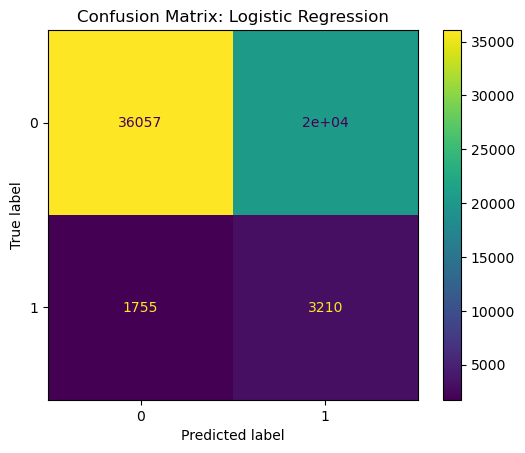

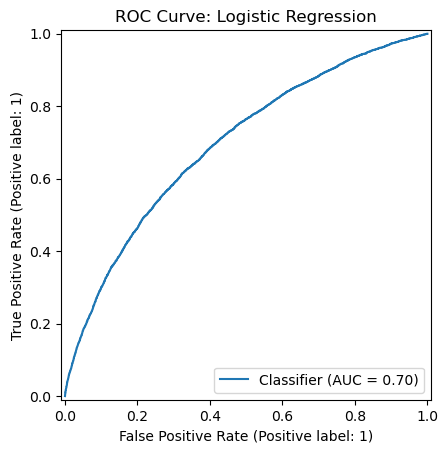

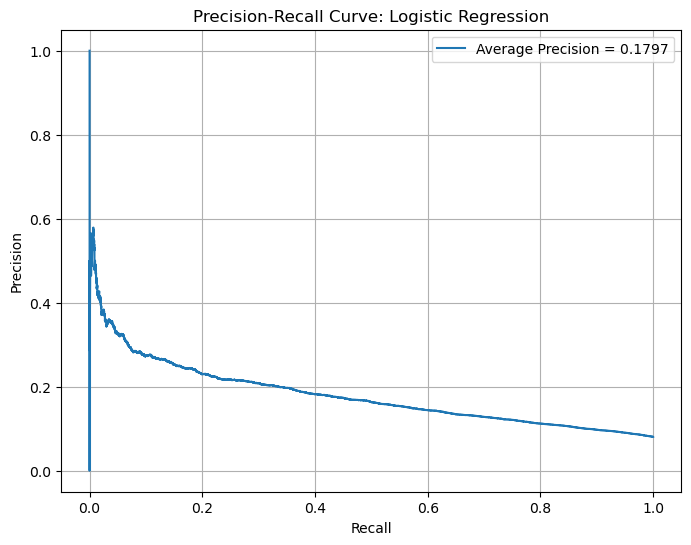

In [32]:
# evaluate Logistic Regression:
logistic_evaluator = ModelEvaluator(
    model=model_trainer.models["Logistic Regression"],
    model_name="Logistic Regression",
    X_test=X_test,
    y_test=y_test
)

logistic_evaluator.evaluate()
logistic_evaluator.calculate_ks_gini()
logistic_evaluator.plot_confusion_matrix()
logistic_evaluator.plot_roc_curve()
logistic_evaluator.plot_precision_recall_curve()

MODEL EVALUATION: Decision Tree

Accuracy: 0.8614
Precision: 0.1487
Recall: 0.1517
F1 Score: 0.1502
ROC-AUC: 0.5377

Confusion Matrix:
[[52227  4311]
 [ 4212   753]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     56538
           1       0.15      0.15      0.15      4965

    accuracy                           0.86     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.86      0.86     61503

KS AND GINI: Decision Tree

KS Statistic: 0.0754
ROC-AUC: 0.5377
Gini Coefficient: 0.0754


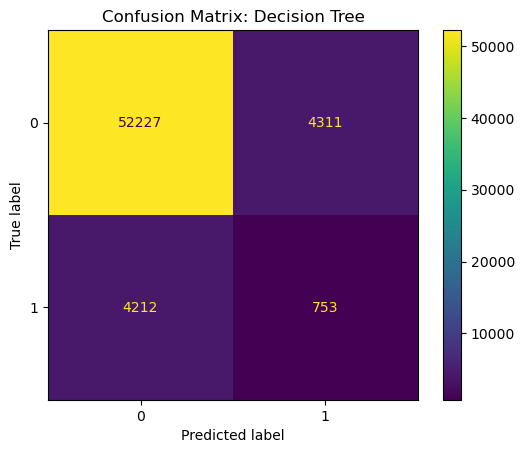

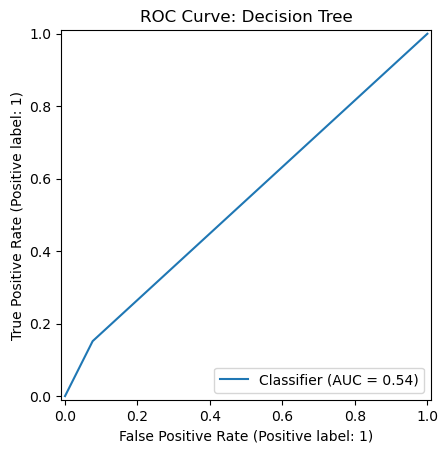

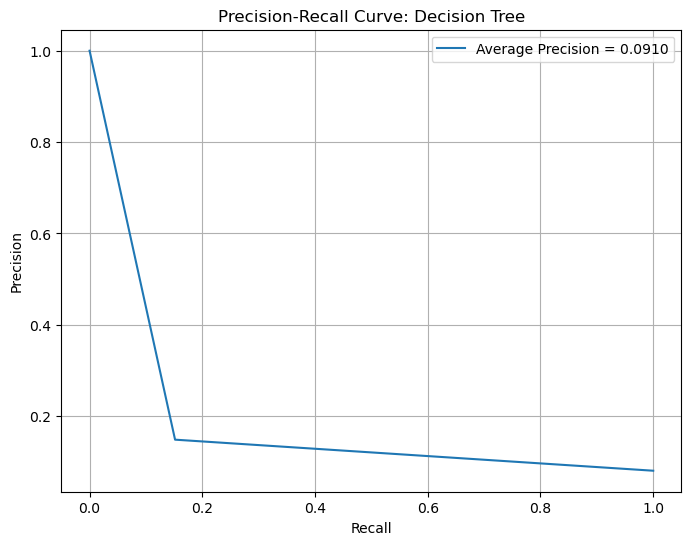

In [33]:
# For Decision Tree:
decision_tree_evaluator = ModelEvaluator(
    model=model_trainer.models["Decision Tree"],
    model_name="Decision Tree",
    X_test=X_test,
    y_test=y_test
)

decision_tree_evaluator.evaluate()
decision_tree_evaluator.calculate_ks_gini()
decision_tree_evaluator.plot_confusion_matrix()
decision_tree_evaluator.plot_roc_curve()
decision_tree_evaluator.plot_precision_recall_curve()

MODEL EVALUATION: Random Forest

Accuracy: 0.9088
Precision: 0.3476
Recall: 0.1484
F1 Score: 0.208
ROC-AUC: 0.7413

Confusion Matrix:
[[55155  1383]
 [ 4228   737]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56538
           1       0.35      0.15      0.21      4965

    accuracy                           0.91     61503
   macro avg       0.64      0.56      0.58     61503
weighted avg       0.88      0.91      0.89     61503

KS AND GINI: Random Forest

KS Statistic: 0.3589
ROC-AUC: 0.7413
Gini Coefficient: 0.4827


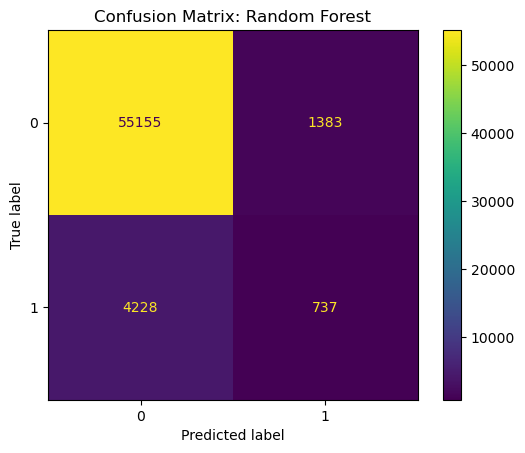

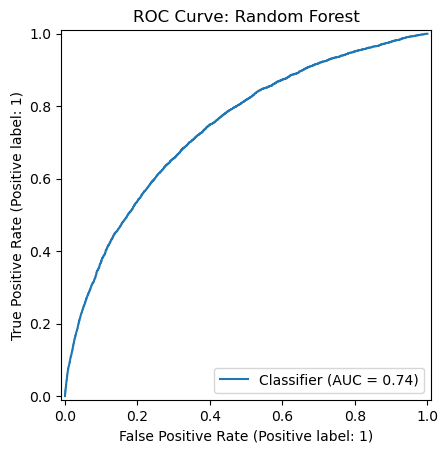

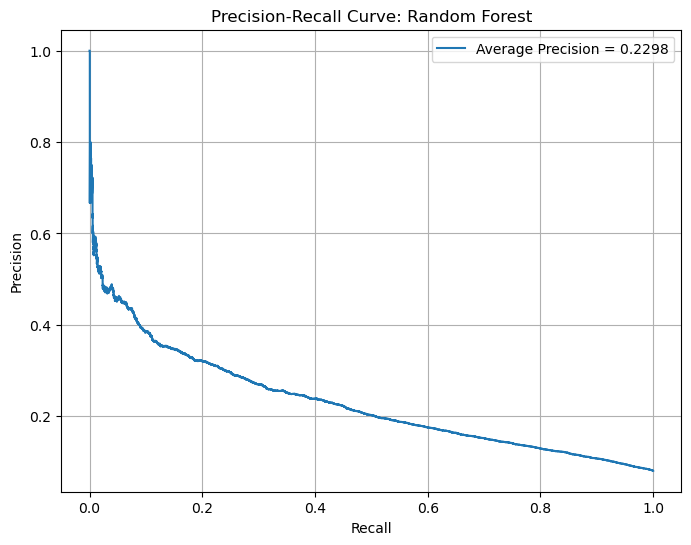

In [34]:
# For Random Forest:

rf_evaluator = ModelEvaluator(
    model=model_trainer.models["Random Forest"],
    model_name="Random Forest",
    X_test=X_test,
    y_test=y_test
)

rf_evaluator.evaluate()
rf_evaluator.calculate_ks_gini()
rf_evaluator.plot_confusion_matrix()
rf_evaluator.plot_roc_curve()
rf_evaluator.plot_precision_recall_curve()

MODEL EVALUATION: Tuned Random Forest

Accuracy: 0.7256
Precision: 0.1717
Recall: 0.6274
F1 Score: 0.2696
ROC-AUC: 0.7468

Confusion Matrix:
[[41510 15028]
 [ 1850  3115]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.17      0.63      0.27      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.68      0.55     61503
weighted avg       0.89      0.73      0.79     61503

KS AND GINI: Tuned Random Forest

KS Statistic: 0.3713
ROC-AUC: 0.7468
Gini Coefficient: 0.4937


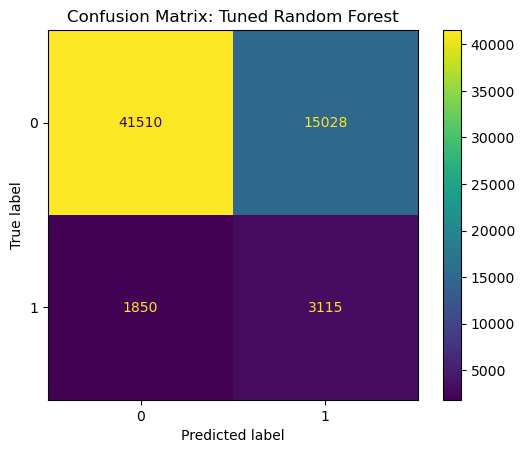

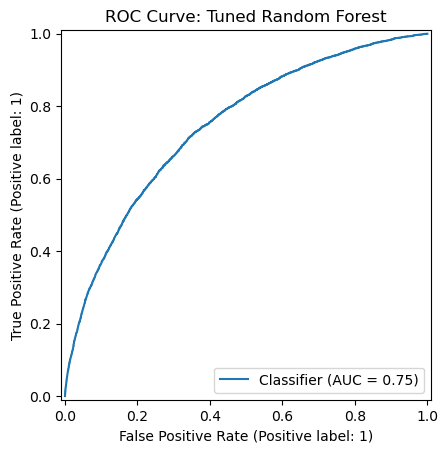

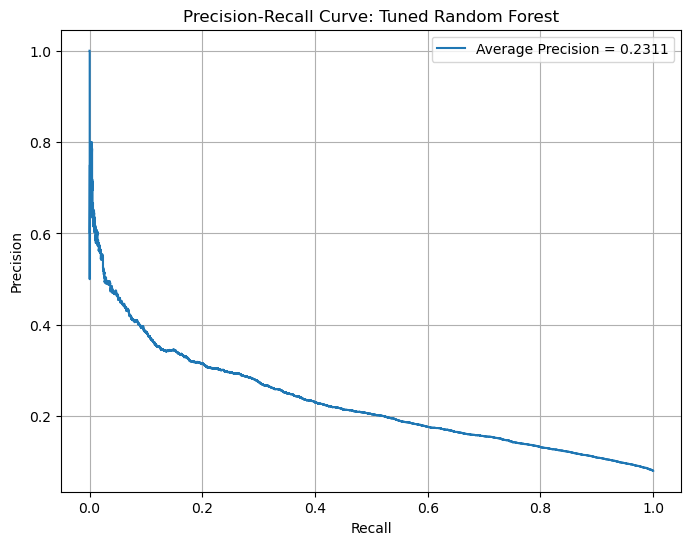

In [35]:
# For Tuned Random Forest:
tuned_rf_evaluator = ModelEvaluator(
    model=model_trainer.models["Tuned Random Forest"],
    model_name="Tuned Random Forest",
    X_test=X_test,
    y_test=y_test
)

tuned_rf_evaluator.evaluate()
tuned_rf_evaluator.calculate_ks_gini()
tuned_rf_evaluator.plot_confusion_matrix()
tuned_rf_evaluator.plot_roc_curve()
tuned_rf_evaluator.plot_precision_recall_curve()

In [36]:
logistic_evaluator.calculate_ks_gini()

decision_tree_evaluator.calculate_ks_gini()

rf_evaluator.calculate_ks_gini()

tuned_rf_evaluator.calculate_ks_gini()

KS AND GINI: Logistic Regression

KS Statistic: 0.291
ROC-AUC: 0.6957
Gini Coefficient: 0.3914
KS AND GINI: Decision Tree

KS Statistic: 0.0754
ROC-AUC: 0.5377
Gini Coefficient: 0.0754
KS AND GINI: Random Forest

KS Statistic: 0.3589
ROC-AUC: 0.7413
Gini Coefficient: 0.4827
KS AND GINI: Tuned Random Forest

KS Statistic: 0.3713
ROC-AUC: 0.7468
Gini Coefficient: 0.4937


Final comparison:

| Model                   |   Accuracy | Precision (Default=1) | Recall (Default=1) |   F1 Score |    ROC-AUC |
| ----------------------- | ---------: | --------------------: | -----------------: | ---------: | ---------: |
| Logistic Regression     |     0.6385 |                0.1355 |         **0.6465** |     0.2240 |     0.6957 |
| Decision Tree           |     0.8614 |                0.1487 |             0.1517 |     0.1502 |     0.5377 |
| Random Forest           | **0.9088** |            **0.3476** |             0.1484 |     0.2080 |     0.7413 |
| **Tuned Random Forest** |     0.7256 |                0.1717 |             0.6274 | **0.2696** | **0.7468** |


| Metric          | Logistic Regression | Tuned Random Forest |
| --------------- | ------------------: | ------------------: |
| Recall          |          **0.6465** |              0.6274 |
| F1 Score        |              0.2240 |          **0.2696** |
| ROC-AUC         |              0.6957 |          **0.7468** |
| False Negatives |           **1,755** |               1,850 |


FINAL PROJECT COMPARISON
│
├── Logistic Regression
│      └── Traditional interpretable scorecard
│
└── Tuned Random Forest
       └── Best predictive/challenger model

1) Final traditional scorecard model: Logistic Regression
2) Best predictive challenger model: Tuned Random Forest
3) Reject: Decision Tree
4) Do not select Random Forest solely because of 90.88% accuracy

Updated final model comparison:

| Model                   |    ROC-AUC | KS Statistic |       Gini | Key observation                |
| ----------------------- | ---------: | -----------: | ---------: | ------------------------------ |
| Logistic Regression     |     0.6957 |       0.2910 |     0.3914 | Good baseline, interpretable   |
| Decision Tree           |     0.5377 |       0.0754 |     0.0754 | Very weak discrimination       |
| Random Forest           |     0.7413 |       0.3589 |     0.4827 | Strong predictive performance  |
| **Tuned Random Forest** | **0.7468** |   **0.3713** | **0.4937** | 🥇 Best predictive performance |


### 17. SHAPAnalyzer

In [50]:
# ============================================================
# SHAP ANALYZER
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


class SHAPAnalyzer:

    def __init__(
        self,
        model,
        X_train,
        X_test,
        sample_size=5000,
        random_state=42
    ):

        self.model = model
        self.X_train = X_train
        self.X_test = X_test

        self.sample_size = sample_size
        self.random_state = random_state

        self.X_shap_sample = None
        self.explainer = None
        self.shap_values = None
        self.expected_value = None

    # ========================================================
    # 1. CREATE REPRESENTATIVE SAMPLE
    # ========================================================

    def create_sample(self):

        sample_size = min(
            self.sample_size,
            len(self.X_train)
        )

        self.X_shap_sample = self.X_train.sample(
            n=sample_size,
            random_state=self.random_state
        )

        print("SHAP Sample Created Successfully!")
        print("SHAP Sample Shape:", self.X_shap_sample.shape)

        return self.X_shap_sample

    # ========================================================
    # 2. CREATE SHAP EXPLAINER
    # ========================================================

    def create_explainer(self):

        if self.X_shap_sample is None:
            self.create_sample()

        self.explainer = shap.TreeExplainer(
            self.model
        )

        print("SHAP TreeExplainer Created Successfully!")

        return self.explainer

    # ========================================================
    # 3. CALCULATE SHAP VALUES
    # ========================================================

    def calculate_shap_values(self):

        if self.explainer is None:
            self.create_explainer()

        raw_shap_values = self.explainer(
            self.X_shap_sample
        )

        # ----------------------------------------------------
        # Handle binary classification output
        # ----------------------------------------------------

        if raw_shap_values.values.ndim == 3:

            # Class 1 = Default
            self.shap_values = shap.Explanation(
                values=raw_shap_values.values[:, :, 1],
                base_values=raw_shap_values.base_values[:, 1],
                data=raw_shap_values.data,
                feature_names=raw_shap_values.feature_names
            )

        else:

            self.shap_values = raw_shap_values

        print("SHAP Values Calculated Successfully!")
        print("SHAP Values Shape:", self.shap_values.values.shape)

        return self.shap_values

    # ========================================================
    # 4. SHAP SUMMARY PLOT
    # ========================================================

    def summary_plot(self):

        if self.shap_values is None:
            self.calculate_shap_values()

        print("Generating SHAP Summary Plot...")

        shap.plots.beeswarm(
            self.shap_values,
            max_display=20,
            show=True
        )

    # ========================================================
    # 5. SHAP FEATURE IMPORTANCE
    # ========================================================

    def feature_importance(self):

        if self.shap_values is None:
            self.calculate_shap_values()

        importance = np.abs(
            self.shap_values.values
        ).mean(axis=0)

        feature_importance_df = pd.DataFrame({

            "Feature":
                self.X_shap_sample.columns,

            "Mean_Absolute_SHAP":
                importance

        })

        feature_importance_df = (
            feature_importance_df
            .sort_values(
                by="Mean_Absolute_SHAP",
                ascending=False
            )
            .reset_index(drop=True)
        )

        print("\nTop 20 SHAP Features:")

        display(
            feature_importance_df.head(20)
        )

        return feature_importance_df

    # ========================================================
    # 6. SHAP FEATURE IMPORTANCE BAR PLOT
    # ========================================================

    def feature_importance_plot(self):

        if self.shap_values is None:
            self.calculate_shap_values()

        shap.plots.bar(
            self.shap_values,
            max_display=20,
            show=True
        )

    # ========================================================
    # 7. SHAP DEPENDENCE PLOT
    # ========================================================

    def dependence_plot(self, feature):

        if self.shap_values is None:
            self.calculate_shap_values()

        shap.plots.scatter(
            self.shap_values[:, feature],
            color=self.shap_values,
            show=True
        )

    # ========================================================
    # 8. EXPLAIN ONE APPLICANT
    # ========================================================

    def explain_single_prediction(self, X_instance):

        if self.explainer is None:
            self.create_explainer()

        raw_values = self.explainer(X_instance)

        # Handle binary classification
        if raw_values.values.ndim == 3:

            instance_shap = shap.Explanation(
                values=raw_values.values[:, :, 1],
                base_values=raw_values.base_values[:, 1],
                data=raw_values.data,
                feature_names=raw_values.feature_names
            )

        else:

            instance_shap = raw_values

        shap.plots.waterfall(
            instance_shap[0],
            max_display=15
        )

        return instance_shap

In [51]:
# ============================================================
# CREATE SHAP ANALYZER
# ============================================================

shap_analyzer = SHAPAnalyzer(
    model=model_trainer.best_model,
    X_train=model_trainer.X_train,
    X_test=model_trainer.X_test,
    sample_size=5000,
    random_state=42
)

print("SHAP Analyzer Created Successfully!")

SHAP Analyzer Created Successfully!


In [52]:
# ============================================================
# STEP 1: CREATE SHAP SAMPLE
# ============================================================

shap_analyzer.create_sample()

SHAP Sample Created Successfully!
SHAP Sample Shape: (5000, 40)


,CODE_GENDER,AMT_CREDIT,AMT_GOODS_PRICE,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,...,DOCUMENT_COMPLETENESS_SCORE,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married
214099,0,1381113.0,1206000.0,-2119,1,1,1,0.646429,0.636376,0.0278,...,2,1,0,0,0,1,0,0,0,0
95916,1,227520.0,180000.0,-145,1,2,2,0.489092,0.535276,0.0876,...,1,0,0,0,1,0,0,0,1,1
40268,0,848745.0,675000.0,-5321,1,2,2,0.423273,0.127699,0.0876,...,1,0,0,0,1,0,0,0,1,1
305371,1,1264428.0,990000.0,-4659,1,1,1,0.768021,0.667458,0.0876,...,1,0,0,1,0,1,0,0,0,1
198031,0,202500.0,202500.0,-3123,1,3,3,0.669503,0.764939,0.0247,...,1,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11358,1,274500.0,274500.0,-572,1,2,2,0.368979,0.448962,0.0876,...,1,0,0,0,1,0,0,0,1,0
242341,0,191880.0,180000.0,-4164,0,2,2,0.431498,0.535276,0.0876,...,1,0,1,0,0,0,0,0,1,0
305528,0,564124.5,481500.0,-2401,1,1,1,0.548309,0.569149,0.1716,...,1,1,0,0,0,0,0,0,1,1
34200,0,203760.0,180000.0,-2901,1,2,2,0.020436,0.610991,0.0392,...,1,0,0,0,1,0,0,0,1,1


In [53]:
# ============================================================
# STEP 2: CREATE EXPLAINER
# ============================================================

shap_analyzer.create_explainer()

SHAP TreeExplainer Created Successfully!


In [54]:
# ============================================================
# STEP 3: CALCULATE SHAP VALUES
# ============================================================

shap_analyzer.calculate_shap_values()

SHAP Values Calculated Successfully!
SHAP Values Shape: (5000, 40)


.values =
array([[-3.74700531e-03, -6.50814718e-03, -1.60307073e-02, ...,
        -5.72706020e-05, -1.49052064e-02,  3.36836314e-03],
       [ 1.82830514e-02, -6.34926628e-03,  4.55074743e-03, ...,
        -4.66646743e-05,  4.77806659e-03, -2.47074867e-03],
       [-3.84991288e-03, -3.44077538e-04, -1.15306394e-04, ...,
        -1.34776750e-05,  4.56425394e-03, -5.41605448e-04],
       ...,
       [-1.16577998e-02,  4.70406269e-03,  4.03098066e-03, ...,
        -5.29801463e-05,  4.45393662e-03, -1.77254707e-03],
       [-8.73488764e-03, -1.84208185e-02, -7.12578353e-03, ...,
        -3.35557453e-05,  4.28425055e-03, -1.15633753e-03],
       [ 1.89937443e-02,  6.39298859e-04, -1.76037187e-02, ...,
        -6.79654595e-05,  8.08179956e-03, -1.55877231e-03]],
      shape=(5000, 40))

.base_values =
array([0.49989139, 0.49989139, 0.49989139, ..., 0.49989139, 0.49989139,
       0.49989139], shape=(5000,))

.data =
array([[0.000000e+00, 1.381113e+06, 1.206000e+06, ..., 0.000000e+00,
        

Generating SHAP Summary Plot...


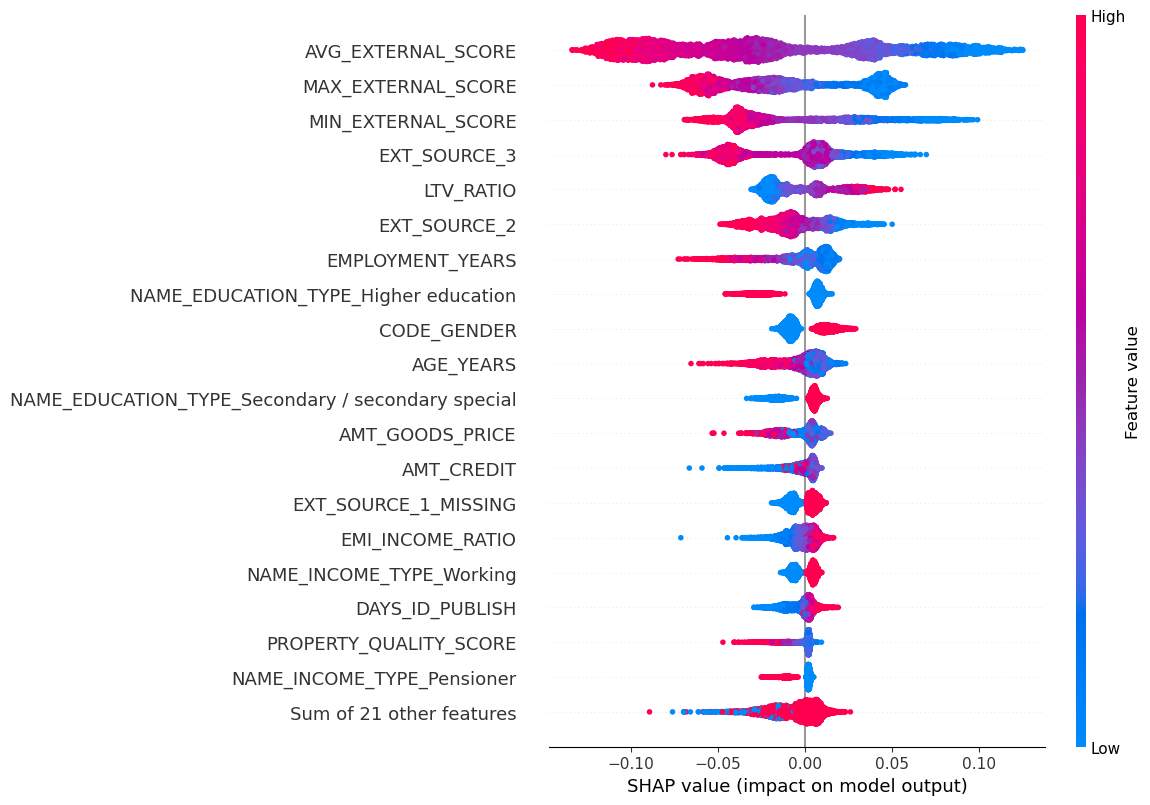

In [55]:
# ============================================================
# STEP 4: SHAP SUMMARY PLOT
# ============================================================

shap_analyzer.summary_plot()

1) Positive SHAP value → pushes prediction toward default
2) Negative SHAP value → pushes prediction toward non-default
3) Larger absolute SHAP value → stronger influence on the prediction

In [56]:
# ============================================================
# STEP 5: FEATURE IMPORTANCE
# ============================================================

shap_importance = shap_analyzer.feature_importance()


Top 20 SHAP Features:


,Feature,Mean_Absolute_SHAP
0,AVG_EXTERNAL_SCORE,0.062407
1,MAX_EXTERNAL_SCORE,0.037542
2,MIN_EXTERNAL_SCORE,0.036553
3,EXT_SOURCE_3,0.026086
4,LTV_RATIO,0.017825
5,EXT_SOURCE_2,0.015518
6,EMPLOYMENT_YEARS,0.013269
7,NAME_EDUCATION_TYPE_Higher education,0.012002
8,CODE_GENDER,0.010413
9,AGE_YEARS,0.010185


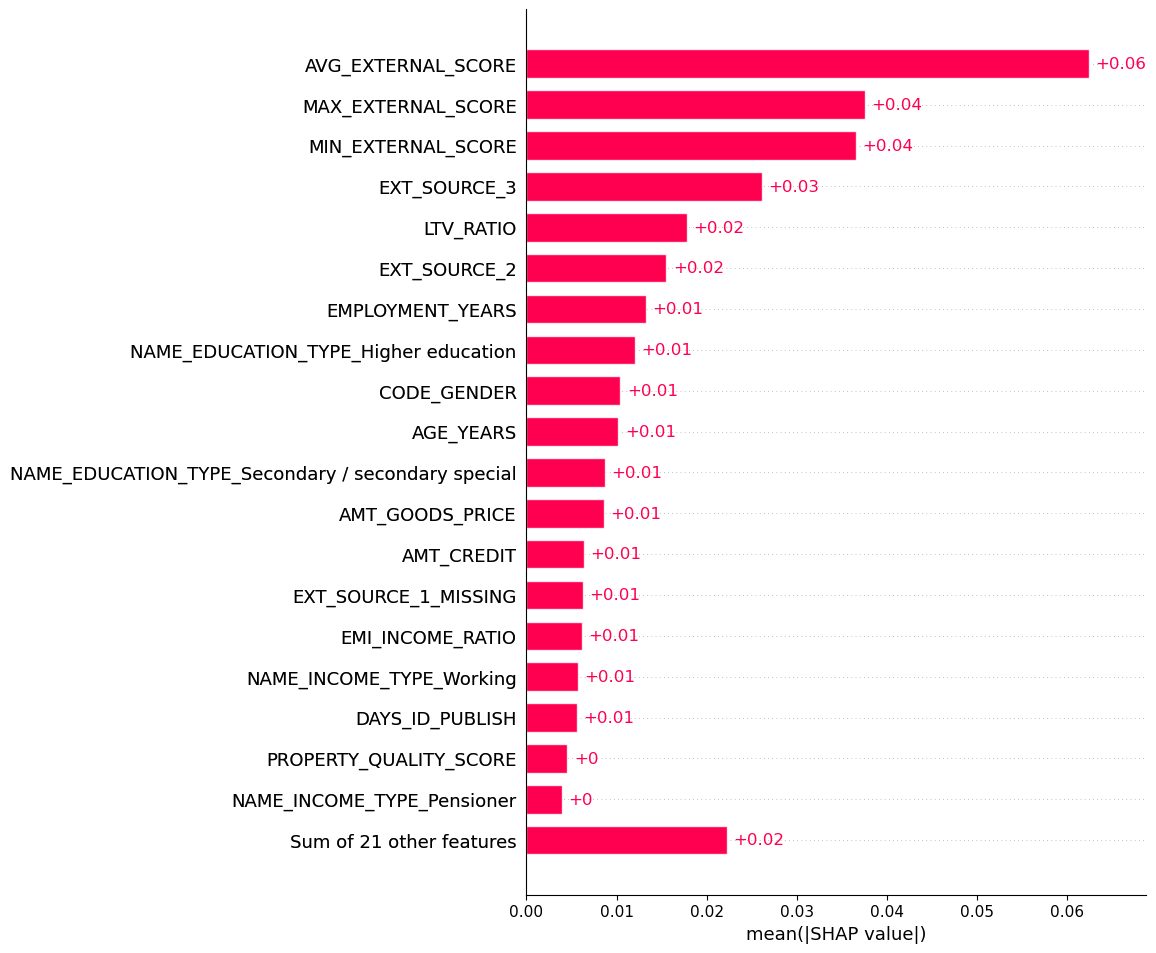

In [57]:
# ============================================================
# STEP 6: FEATURE IMPORTANCE BAR PLOT
# ============================================================

shap_analyzer.feature_importance_plot()

### Test a new applicant now

In [58]:
# ============================================================
# PREDICTION CLASS
# ============================================================

import pandas as pd
import numpy as np


class Prediction:

    def __init__(self, model, feature_names):

        self.model = model
        self.feature_names = feature_names

    # --------------------------------------------------------
    # Validate new applicant data
    # --------------------------------------------------------

    def validate_input(self, X_new):

        missing_features = [
            feature
            for feature in self.feature_names
            if feature not in X_new.columns
        ]

        extra_features = [
            feature
            for feature in X_new.columns
            if feature not in self.feature_names
        ]

        if missing_features:
            raise ValueError(
                f"Missing features: {missing_features}"
            )

        if extra_features:
            X_new = X_new.drop(
                columns=extra_features
            )

        # Ensure correct feature order
        X_new = X_new[
            self.feature_names
        ]

        return X_new

    # --------------------------------------------------------
    # Predict default probability
    # --------------------------------------------------------

    def predict_probability(self, X_new):

        X_new = self.validate_input(X_new)

        probability = self.model.predict_proba(
            X_new
        )[:, 1]

        return probability

    # --------------------------------------------------------
    # Predict class
    # --------------------------------------------------------

    def predict_class(self, X_new):

        X_new = self.validate_input(X_new)

        prediction = self.model.predict(
            X_new
        )

        return prediction

    # --------------------------------------------------------
    # Generate final prediction report
    # --------------------------------------------------------

    def predict(self, X_new):

        probability = self.predict_probability(
            X_new
        )[0]

        prediction = self.predict_class(
            X_new
        )[0]

        if prediction == 1:
            decision = "Default Risk"
        else:
            decision = "Non-Default Risk"

        return pd.DataFrame({
            "Default_Probability": [
                probability
            ],
            "Default_Probability_Percent": [
                probability * 100
            ],
            "Predicted_Class": [
                prediction
            ],
            "Risk_Decision": [
                decision
            ]
        })

In [59]:
# ============================================================
# CREATE PREDICTION OBJECT
# ============================================================

prediction_model = Prediction(
    model=model_trainer.best_model,
    feature_names=X_train.columns.tolist()
)

print("Prediction Model Created Successfully!")
print("Number of Expected Features:",
      len(X_train.columns))

Prediction Model Created Successfully!
Number of Expected Features: 40


In [60]:
# ============================================================
# DISPLAY FINAL 40 FEATURES
# ============================================================

print("Final Model Features:")

for i, feature in enumerate(X_train.columns, start=1):
    print(f"{i:2}. {feature}")

Final Model Features:
 1. CODE_GENDER
 2. AMT_CREDIT
 3. AMT_GOODS_PRICE
 4. DAYS_ID_PUBLISH
 5. FLAG_EMP_PHONE
 6. REGION_RATING_CLIENT
 7. REGION_RATING_CLIENT_W_CITY
 8. EXT_SOURCE_2
 9. EXT_SOURCE_3
10. APARTMENTS_AVG
11. OBS_30_CNT_SOCIAL_CIRCLE
12. OBS_60_CNT_SOCIAL_CIRCLE
13. FLAG_DOCUMENT_4
14. FLAG_DOCUMENT_13
15. FLAG_DOCUMENT_14
16. FLAG_DOCUMENT_16
17. FLAG_DOCUMENT_17
18. FLAG_DOCUMENT_18
19. EXT_SOURCE_1_MISSING
20. AGE_YEARS
21. EMPLOYMENT_DATA_UNAVAILABLE
22. EMPLOYMENT_YEARS
23. INCOME_CATEGORY
24. EMI_INCOME_RATIO
25. LTV_RATIO
26. OWNS_VEHICLE
27. AVG_EXTERNAL_SCORE
28. MAX_EXTERNAL_SCORE
29. MIN_EXTERNAL_SCORE
30. PROPERTY_QUALITY_SCORE
31. DOCUMENT_COMPLETENESS_SCORE
32. NAME_INCOME_TYPE_Commercial associate
33. NAME_INCOME_TYPE_Pensioner
34. NAME_INCOME_TYPE_State servant
35. NAME_INCOME_TYPE_Working
36. NAME_EDUCATION_TYPE_Higher education
37. NAME_EDUCATION_TYPE_Incomplete higher
38. NAME_EDUCATION_TYPE_Lower secondary
39. NAME_EDUCATION_TYPE_Secondary / seconda

In [61]:
# ============================================================
# STEP 4: CREATE NEW APPLICANT
# ============================================================

new_applicant = pd.DataFrame([{

    # --------------------------------------------------------
    # Basic Applicant Information
    # --------------------------------------------------------

    "CODE_GENDER": 1,

    # --------------------------------------------------------
    # Loan Information
    # --------------------------------------------------------

    "AMT_CREDIT": 500000.0,
    "AMT_GOODS_PRICE": 625000.0,

    # --------------------------------------------------------
    # Applicant History
    # --------------------------------------------------------

    "DAYS_ID_PUBLISH": -2500,

    # --------------------------------------------------------
    # Employment / Region
    # --------------------------------------------------------

    "FLAG_EMP_PHONE": 1,
    "REGION_RATING_CLIENT": 2,
    "REGION_RATING_CLIENT_W_CITY": 2,

    # --------------------------------------------------------
    # External Credit Scores
    # --------------------------------------------------------

    "EXT_SOURCE_2": 0.65,
    "EXT_SOURCE_3": 0.70,

    # --------------------------------------------------------
    # Property
    # --------------------------------------------------------

    "APARTMENTS_AVG": 0.15,

    # --------------------------------------------------------
    # Social Circle
    # --------------------------------------------------------

    "OBS_30_CNT_SOCIAL_CIRCLE": 2,
    "OBS_60_CNT_SOCIAL_CIRCLE": 2,

    # --------------------------------------------------------
    # Document Flags
    # --------------------------------------------------------

    "FLAG_DOCUMENT_4": 0,
    "FLAG_DOCUMENT_13": 0,
    "FLAG_DOCUMENT_14": 0,
    "FLAG_DOCUMENT_16": 0,
    "FLAG_DOCUMENT_17": 0,
    "FLAG_DOCUMENT_18": 0,

    # --------------------------------------------------------
    # Missing External Score Indicator
    # --------------------------------------------------------

    "EXT_SOURCE_1_MISSING": 0,

    # --------------------------------------------------------
    # Feature Engineering
    # --------------------------------------------------------

    "AGE_YEARS": 35,

    "EMPLOYMENT_DATA_UNAVAILABLE": 0,

    "EMPLOYMENT_YEARS": 8,

    # --------------------------------------------------------
    # Income Category
    #
    # IMPORTANT:
    # Use the same numerical encoding that was used
    # during your training feature engineering.
    # --------------------------------------------------------

    "INCOME_CATEGORY": 2,

    # --------------------------------------------------------
    # Financial Ratios
    # --------------------------------------------------------

    "EMI_INCOME_RATIO": 0.30,

    "LTV_RATIO": 0.80,

    # --------------------------------------------------------
    # Ownership
    # --------------------------------------------------------

    "OWNS_VEHICLE": 1,

    # --------------------------------------------------------
    # External Credit Score Features
    # --------------------------------------------------------

    "AVG_EXTERNAL_SCORE": 0.675,

    "MAX_EXTERNAL_SCORE": 0.70,

    "MIN_EXTERNAL_SCORE": 0.65,

    # --------------------------------------------------------
    # Property Quality
    # --------------------------------------------------------

    "PROPERTY_QUALITY_SCORE": 0.15,

    # --------------------------------------------------------
    # Document Completeness
    # --------------------------------------------------------

    "DOCUMENT_COMPLETENESS_SCORE": 1,

    # --------------------------------------------------------
    # Income Type - One Hot Encoding
    # --------------------------------------------------------

    "NAME_INCOME_TYPE_Commercial associate": 1,
    "NAME_INCOME_TYPE_Pensioner": 0,
    "NAME_INCOME_TYPE_State servant": 0,
    "NAME_INCOME_TYPE_Working": 0,

    # --------------------------------------------------------
    # Education - One Hot Encoding
    # --------------------------------------------------------

    "NAME_EDUCATION_TYPE_Higher education": 1,
    "NAME_EDUCATION_TYPE_Incomplete higher": 0,
    "NAME_EDUCATION_TYPE_Lower secondary": 0,
    "NAME_EDUCATION_TYPE_Secondary / secondary special": 0,

    # --------------------------------------------------------
    # Family Status - One Hot Encoding
    # --------------------------------------------------------

    "NAME_FAMILY_STATUS_Married": 1

}])

print("New Applicant Created Successfully!")

print("\nApplicant Shape:")
print(new_applicant.shape)

print("\nApplicant Data:")
display(new_applicant)

New Applicant Created Successfully!

Applicant Shape:
(1, 40)

Applicant Data:


,CODE_GENDER,AMT_CREDIT,AMT_GOODS_PRICE,DAYS_ID_PUBLISH,FLAG_EMP_PHONE,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,...,DOCUMENT_COMPLETENESS_SCORE,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married
0,1,500000.0,625000.0,-2500,1,2,2,0.65,0.7,0.15,...,1,1,0,0,0,1,0,0,0,1


In [62]:
# ============================================================
# STEP 5: VALIDATE NEW APPLICANT
# ============================================================

missing_features = [
    feature
    for feature in X_train.columns
    if feature not in new_applicant.columns
]

extra_features = [
    feature
    for feature in new_applicant.columns
    if feature not in X_train.columns
]

print("Missing Features:", missing_features)
print("Extra Features:", extra_features)

print(
    "\nFeature Count:",
    len(new_applicant.columns)
)

Missing Features: []
Extra Features: []

Feature Count: 40


In [63]:
# ============================================================
# STEP 6: PREDICT NEW APPLICANT
# ============================================================

prediction_result = prediction_model.predict(
    new_applicant
)

display(prediction_result)

,Default_Probability,Default_Probability_Percent,Predicted_Class,Risk_Decision
0,0.141557,14.155699,0,Non-Default Risk
